# Bank Churn Prediction Project - Neural Network

#### Business Context
Businesses like banks that provide service have to worry about the problem of 'Churn' i.e. customers leaving and joining another service provider. It is important to understand which aspects of the serviceinfluence a customer's decision in this regard. Management can concentrate efforts on the improvement ofservice, keeping in mind these priorities.

#### Objective
Given a Bank customer, build a neural network-based classifier that can determine whether they will leaveor not in the next 6 months.

#### Data Description
The case study is from an open-source dataset from Kaggle. The dataset contains 10,000 sample points with 14 distinct features such as CustomerId, CreditScore,Geography, Gender, Age, Tenure, Balance, etc.

#### Data Dictionary

- CustomerId: Unique ID which is assigned to each customer
- Surname: Last name of the customer
- CreditScore: It defines the credit history of the customer.
- Geography: A customer’s location 
- Gender: It defines the Gender of the customer
- Age: Age of the customer 
- Tenure: Number of years for which the customer has been with the bank
- NumOfProducts: It refers to the number of products that a customer has purchased through the bank
- Balance: Account balance
- HasCrCard: It is a categorical variable that decides whether the customer has a credit card or not.
- EstimatedSalary: Estimated salary 
- isActiveMember:Itis a categorical variable that decides whether the customer is an active member of the bank or not ( Active member in the sense, using bank products regularly, making transactions, etc )
- Exited:It is a categorical variable that decides whether the customer left the bank within six months or not. It can take two values
  - 0=No ( Customer did not leave the bank )
  - 1=Yes ( Customer left the bank )

## Import Libraries

In [0]:
# Installing the libraries with the specified version
!pip install tensorflow==2.18.0 scikit-learn==1.3.2 matplotlib==3.8.3 seaborn==0.13.2 numpy==1.26.4 pandas==2.2.2

In [0]:
%pip install keras-tuner

In [0]:
!pip install imblearn

In [0]:
dbutils.library.restartPython() 

In [0]:
import pandas as pd  # Library for data manipulation and analysis.
import numpy as np   # Fundamental package for scientific computing.
import matplotlib.pyplot as plt  # Plotting library for creating visualizations.
import seaborn as sns #For advanced visualizations.

from sklearn.model_selection import train_test_split  # Function for splitting datasets for training and testing.
from sklearn.preprocessing import StandardScaler

import time  # Module for time-related operations.

import tensorflow as tf #An end-to-end open source machine learning platform
from tensorflow import keras  # High-level neural networks API for deep learning.
from keras import backend   # Abstraction layer for neural network backend engines.
from keras.models import Sequential  # Model for building NN sequentially.
from keras.layers import Dense,Dropout,BatchNormalization   # for creating fully connected neural network layers.

2025-09-21 16:16:40.329472: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-21 16:16:40.330712: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-21 16:16:40.335655: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-21 16:16:40.347875: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758471400.367943  151587 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758471400.37

In [0]:
from tensorflow.keras import layers

## Loading Data

In [0]:
# Read the data from Storage

import os
file_path = os.path.abspath('/Workspace/Users/shaurya.rawat@ukg.com/GreatLearning/1.3 - Neural Network/Assignment/Storage/bank.csv')
bankData = pd.read_csv(file_path, on_bad_lines='skip')

## Data Overview

In [0]:
# Creating the copy of data
data = bankData.copy()

In [0]:
# Check the data shape
data.shape

(10000, 14)

- Contains 10,000 rows and 14 columns

In [0]:
# Checking the top 5 rows
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [0]:
# check the bottom 5 rows
data.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [0]:
# check no of exited and non-exited cases
data['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

- Almost 20% customer left the bank

In [0]:
# Check dataset summary information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


- Dataset has 14 columns and 10,000 rows, dataset is complete with no null values
  - 3 categorical columns - Surname, Geography, Gender
  - 2 floating type columns - Balance, EstimatedSalary

In [0]:
# Checking for the null value in the dataset
data.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [0]:
# Checking for duplicate values
data.duplicated().sum()

0

In [0]:
# check for unique values
data.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

- Rownumber and CustomerID are always unique
- EstimatedSalary is also unique, maybe due to precision of 2, need to be explored 
- Surname is categorical but has high cardinality of 3000 

In [0]:
# Dropping unique columns
data = data.drop('RowNumber', axis=1)
data = data.drop('CustomerId', axis=1)
data = data.drop('Surname', axis = 1)

- Unique columns like Rownumber and CustomrID can not contribute towards the prediction as it leads to overfitting and can't generalize to new unseen data
- Surname is high-cardinality noise for your dataset size (10K rows). Best to drop it

In [0]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


- Now, we have 12 columns and 10,000 entries

In [0]:
# Checking for duplicate values again
data.duplicated().sum()

0

In [0]:
# Check statistical information
data.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


- Customers are 18–92 years old, avg ≈ 39 (slightly younger skew)
- Tenure avg = 5 years, but 25% have <3 years (newer customers dominate)
- Balance distribution: mean 76K, but skewed—50% customers hold >97K, with a max of 250K
- Credit cards: 70% adoption; Active membership: 51%
- Salary distribution: nearly symmetric around 100K, but with a rare outlier (≈11)
- Churn rate = 20% (Exited)

## Exploratory Data Analysis

### Univariate analysis

In [0]:
# function to plot a boxplot and a histogram along the same scale
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

def labeled_barplot(data, feature, perc=False, n=None, max_width=20):
    """
    Barplot with percentage or count labels (Databricks-safe).

    data: dataframe
    feature: dataframe column
    perc: show percentages instead of counts
    n: top n categories (default = all)
    max_width: maximum figure width in inches (default = 20)
    """

    total = len(data[feature])
    count = data[feature].nunique()

    # Limit categories if needed
    if n is None:
        order = data[feature].value_counts().index
    else:
        order = data[feature].value_counts().index[:n]

    # Safe figure width (avoid gigantic sizes)
    width = min((n if n else count) * 0.5 + 3, max_width)

    fig = plt.figure(figsize=(width, 5))
    plt.xticks(rotation=90, fontsize=12)

    # Plot (future-proof seaborn >=0.13)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=order,
        legend=False
    )

    # Annotate each bar
    for p in ax.patches:
        label = "{:.1f}%".format(100 * p.get_height() / total) if perc else p.get_height()
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

    # Display safely in Databricks
    plt.tight_layout()
    display(fig)
    plt.close(fig)


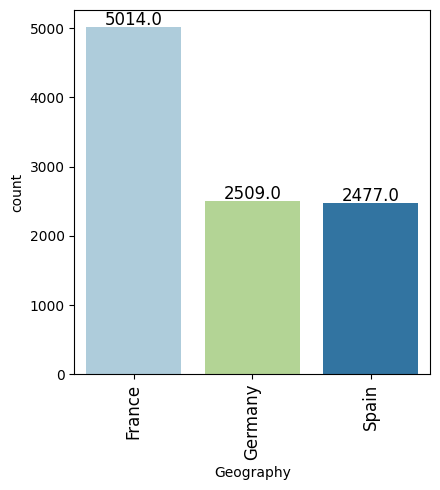

In [0]:
# Observation on surname
labeled_barplot(data, "Geography")

- All Customers are Europians
  - 50% customers are from France
  - Both Germany and Spain have 25% customers each

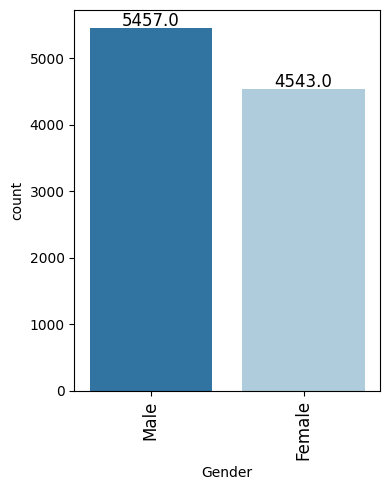

In [0]:
# Observation on surname
labeled_barplot(data, "Gender")

- 54% customers are Male and 46% are Females

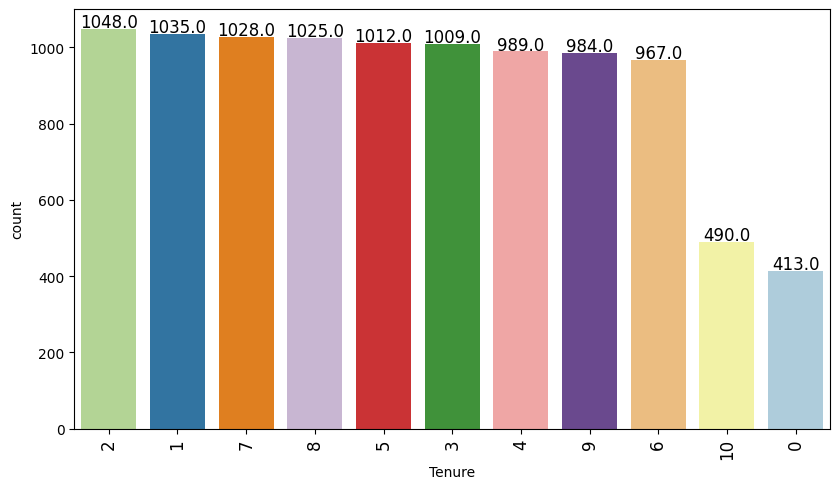

In [0]:
# Observation on surname
labeled_barplot(data, "Tenure")

Tenure is almost uniformly distributed between 1–9 years (~1000 customers each).
Only a smaller share of customers are at the extremes: 0 years (413 customers) and 10 years (490 customers).

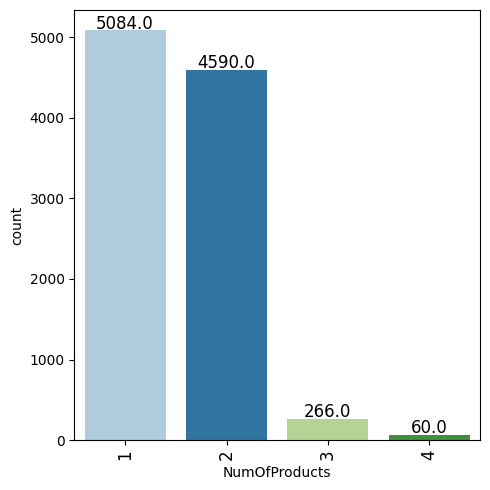

In [0]:
# Observation on surname
labeled_barplot(data, "NumOfProducts")

- The vast majority of customers hold 1 or 2 products
- Customers with 3 or 4 products are extremely rare (only ~3.3% total)
- This feature is highly imbalanced

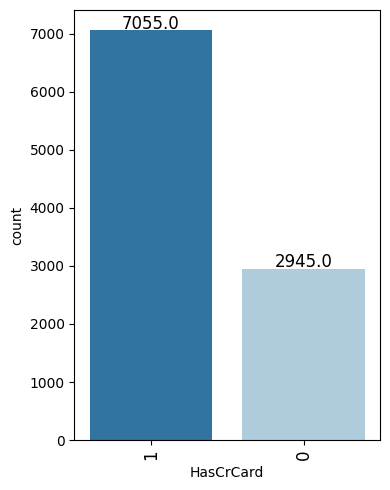

In [0]:
# Observation on surname
labeled_barplot(data, "HasCrCard")

- 70% have credit card

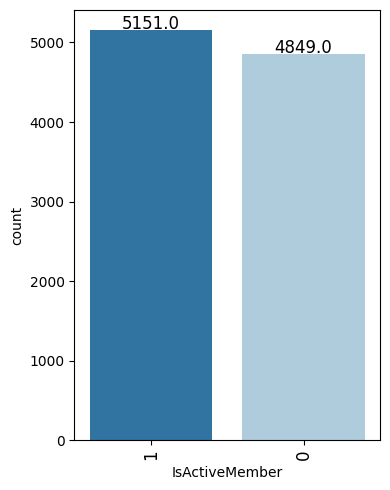

In [0]:
# Observation on surname
labeled_barplot(data, "IsActiveMember")

- Almost balanced category, 51% are active members 

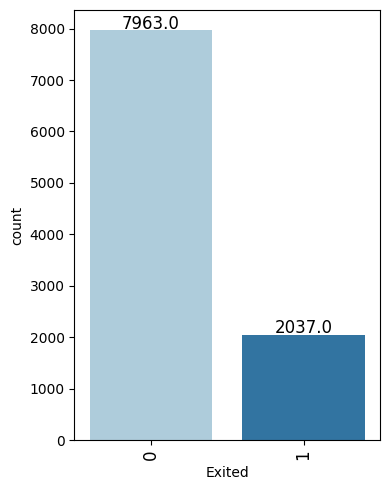

In [0]:
# Observation on surname
labeled_barplot(data, "Exited")

- 20% are churned customers

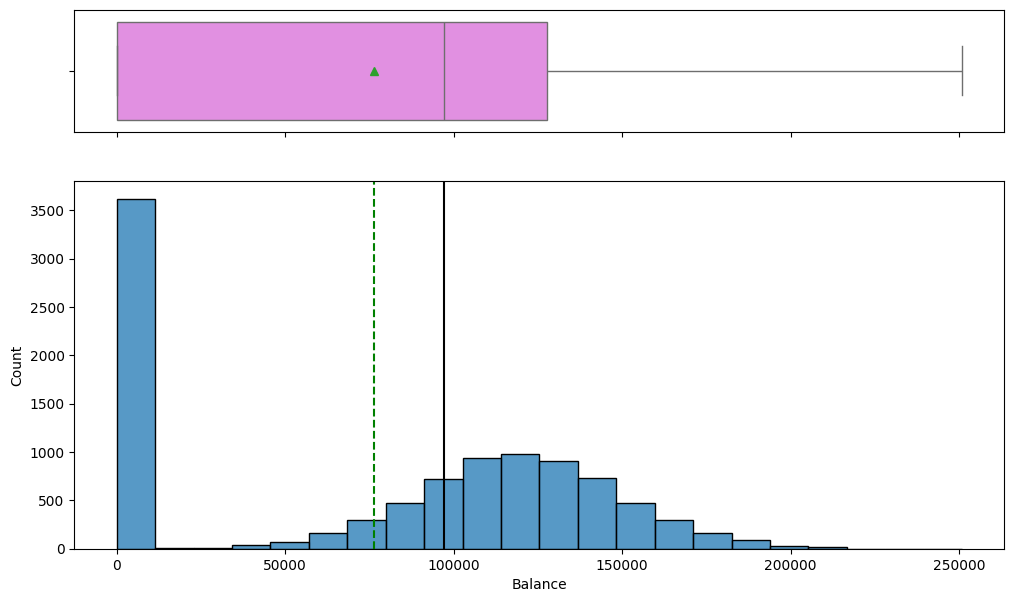

In [0]:
histogram_boxplot(data, 'Balance')

- Balance distribution is right-skewed, ranging from 0 to ~250K
- Around 35% of customers hold zero balance
- Among non-zero customers, balances are fairly normally distributed around 100k
- The mean (76k) is much lower than the median (97k), highlighting the impact of the large zero-balance group

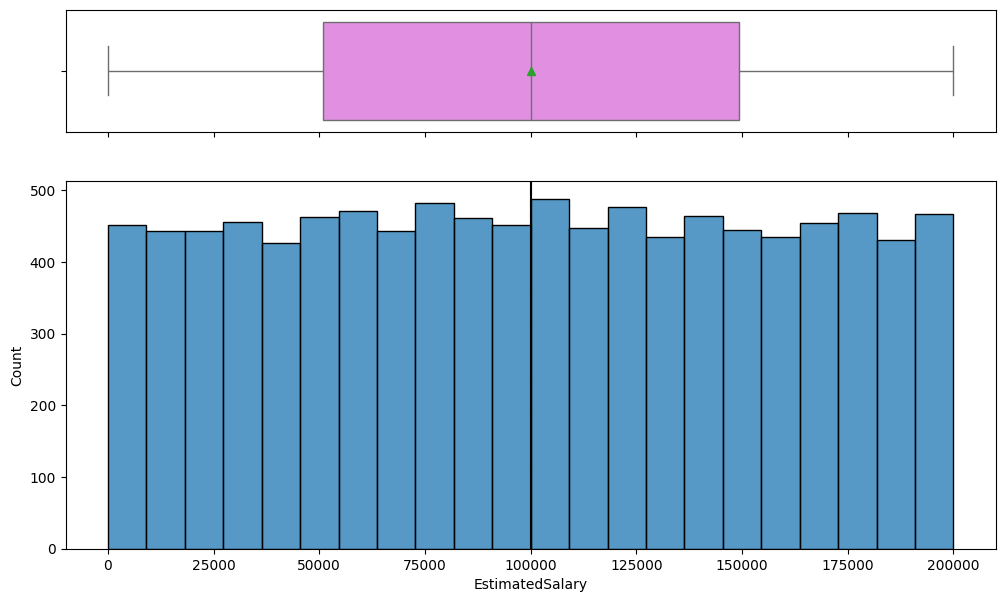

In [0]:
histogram_boxplot(data, 'EstimatedSalary')

- EstimatedSalary is uniformly distributed between 0 and 200k.
- Mean ≈ Median (~100k), no skewness, no significant outliers.
- Likely a weak predictor of churn

### Bivariate Analysis

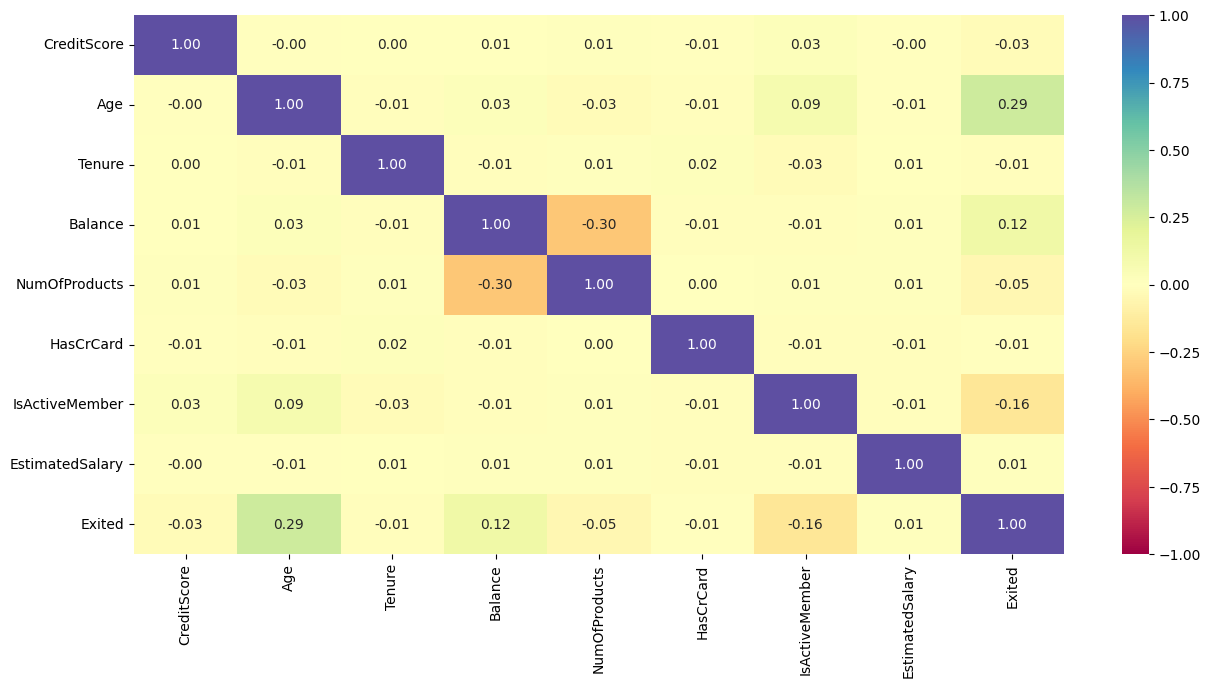

In [0]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

- Age (0.29): Positive correlation: older customers are more likely to exit
- Balance (0.12): Weak positive correlation: higher balance customers slightly more likely to exit
- IsActiveMember (–0.16): Negative correlation: active members are less likely to exit
- NumOfProducts (–0.05): Very weak negative correlation
- Other features (CreditScore, Tenure, HasCrCard, EstimatedSalary) show almost no correlation with churn
- Balance and NumOfProducts (–0.30): Customers with more products tend to have lower balances

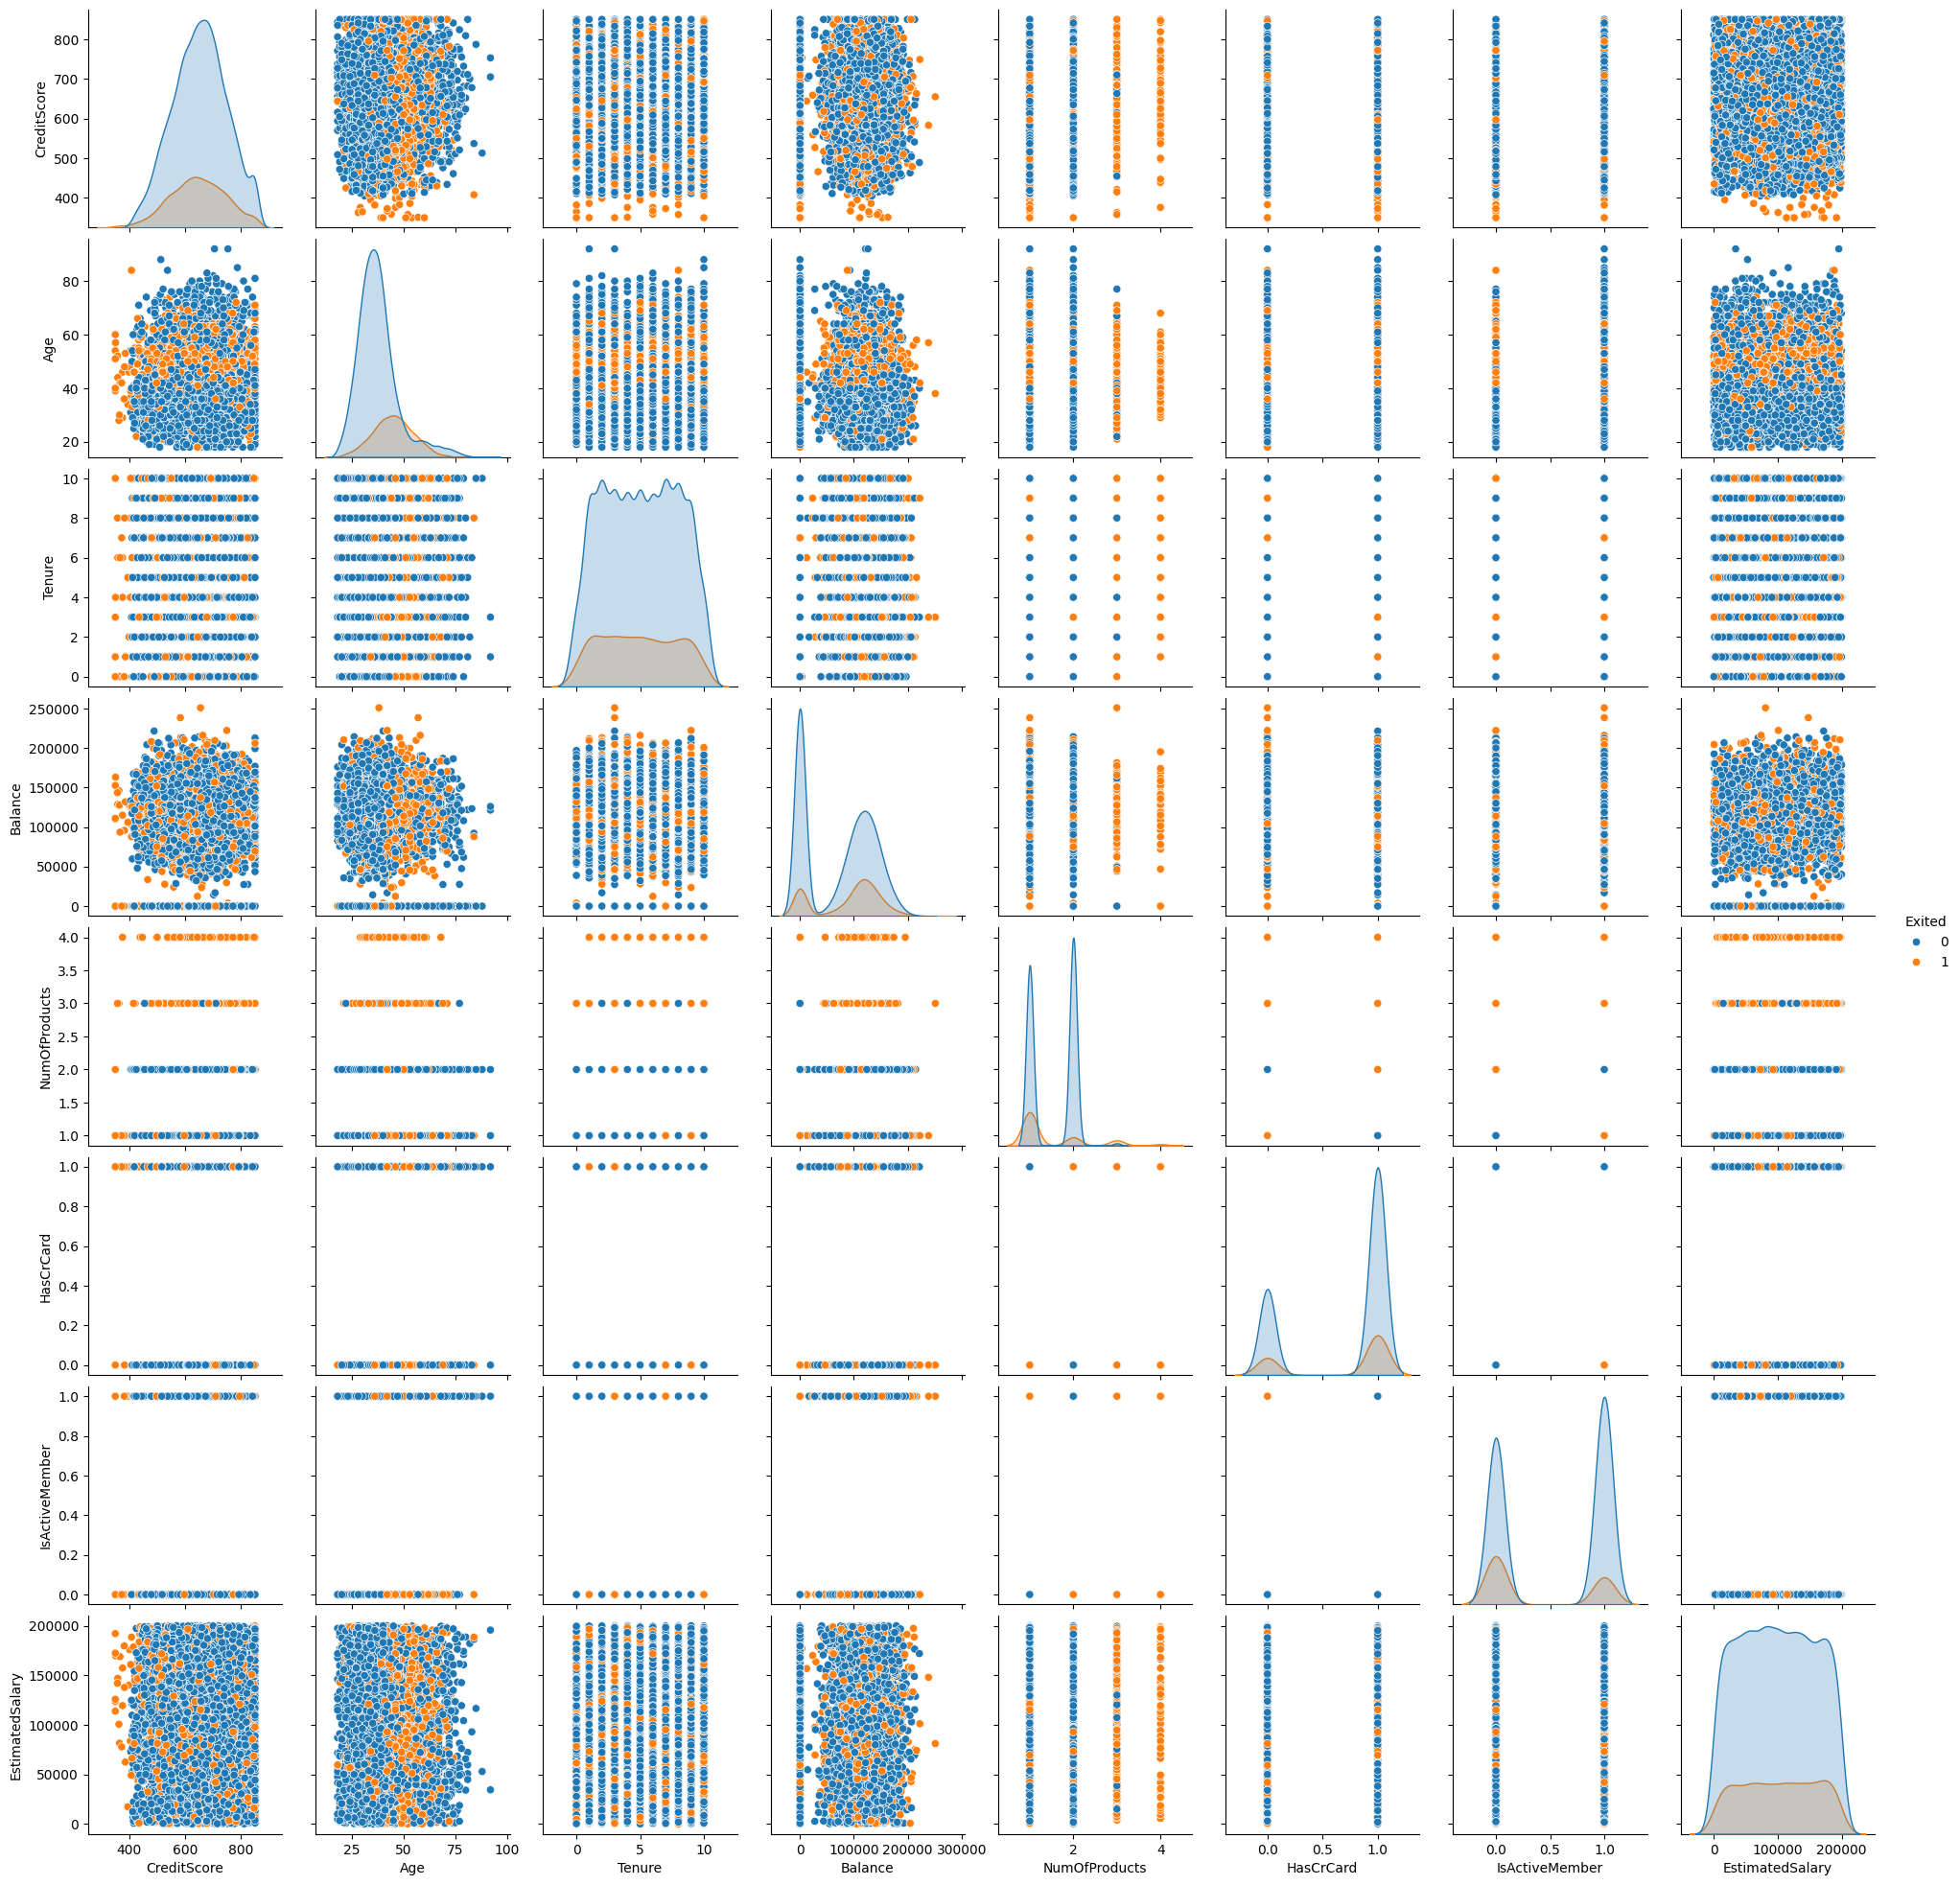

In [0]:
sns.pairplot(data, hue="Exited")

- Age: Customers who churn tend to be older compared to those who stay
- No major noticable effect in other categories

<Axes: xlabel='Exited', ylabel='NumOfProducts'>

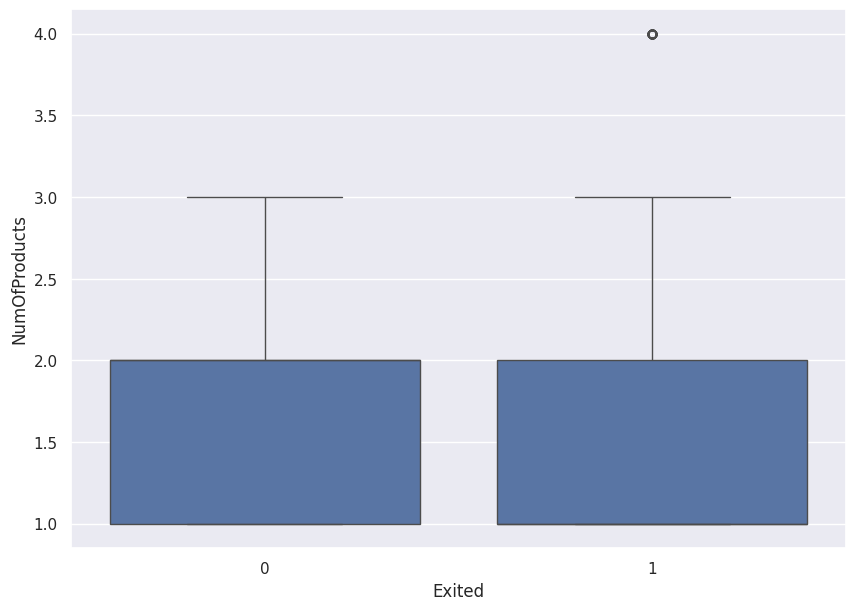

In [0]:
# Visualize the distribution of 'NumOfProducts' across different 'Exited' categories
sns.set(rc={"figure.figsize": (10, 7)})
sns.boxplot(x="Exited", y="NumOfProducts", data=data, orient="vertical")

- Both churned and retained customers typically have 1–2 products
- Outliers (3–4 products) exist, including some churners

<Axes: xlabel='Exited', ylabel='Age'>

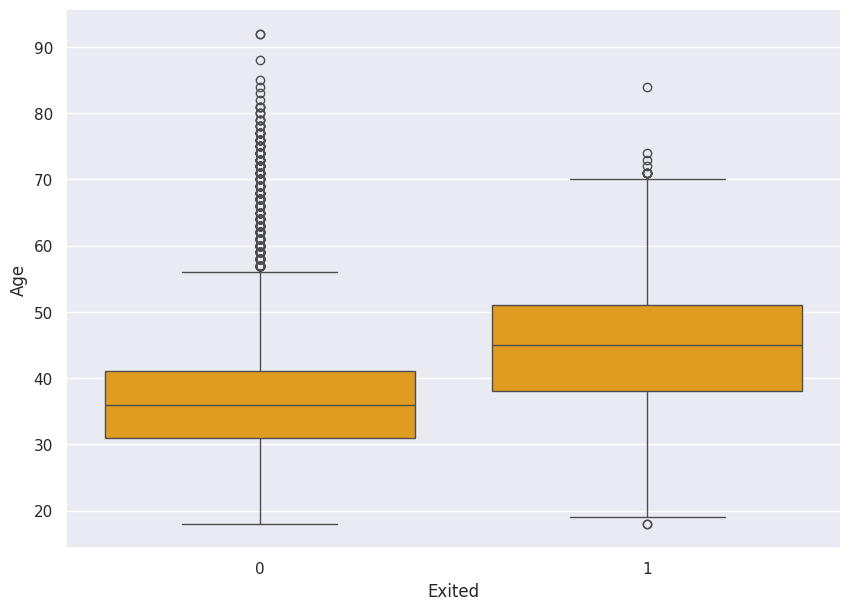

In [0]:
# Visualize the distribution of 'Age' across different 'Exited' categories
sns.set(rc={"figure.figsize": (10, 7)})
sns.boxplot(x="Exited", y="Age", data=data, orient="vertical", color="orange")

- Many outliers in Age vs Exited. Most outliers in non-existed
- Customers who stay are younger (median ~35)
- Customers who churn are older (median ~45)

In [0]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

Exited            0     1    All
NumOfProducts                   
All            7963  2037  10000
1              3675  1409   5084
2              4242   348   4590
3                46   220    266
4                 0    60     60
------------------------------------------------------------------------------------------------------------------------


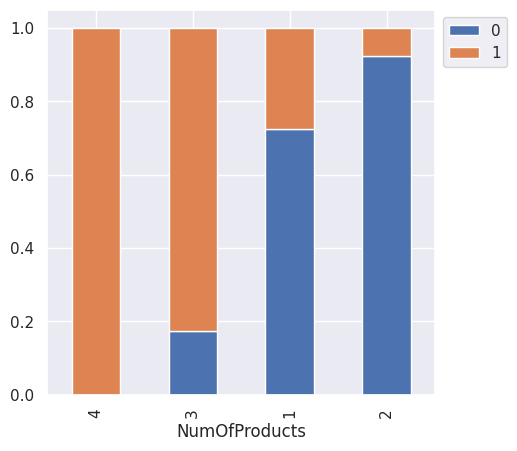

In [0]:
# Visualize the distribution of 'NumOfProducts' across different 'Exited' categories
stacked_barplot(data, "NumOfProducts", "Exited")

- The 1-product group is the largest source of churn in absolute nubers (most churners come from here)
- The 3- and 4-product groups are tiny segments, but churn is very high in percentage terms
- The 2-product group is relatively loyal, with the lowest churn rate

Exited       0     1    All
AgeGroup                   
All       7963  2037  10000
36-45     3003   733   3736
46-55      648   663   1311
26-35     3241   301   3542
56-65      277   259    536
18-25      565    46    611
66-75      185    34    219
76+         44     1     45
------------------------------------------------------------------------------------------------------------------------


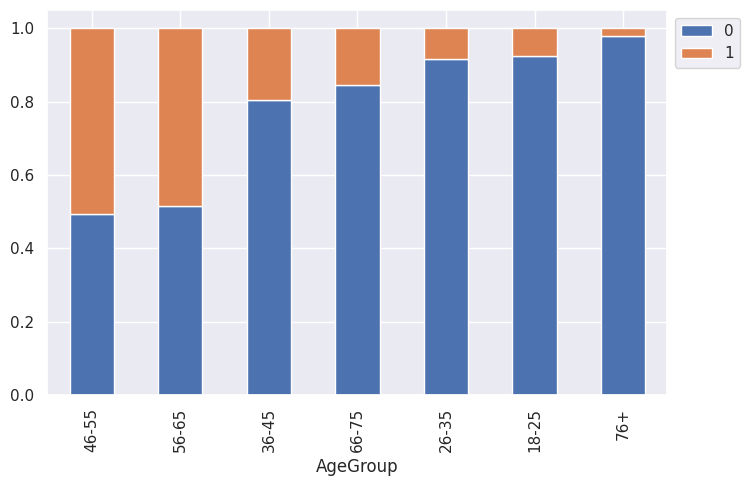

In [0]:
# Visualize the distribution of 'Age' across different 'Exited' categories

df = data.copy()

# Create age bins
bins = [18, 25, 35, 45, 55, 65, 75, 92]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-75', '76+']

df['AgeGroup'] = pd.cut(data['Age'], bins=bins, labels=labels, include_lowest=True)

# Plot churn distribution by age group
stacked_barplot(df, "AgeGroup", "Exited")

- As Age increase, changes of customer churn become high
  - Churn risk peaks between ages 36–55
  - Younger customers (18–35) are more loyal
  - Older customers (66+) are fewer, so churn insights there are less reliable

Exited        0     1    All
HasCrCard                   
All        7963  2037  10000
1          5631  1424   7055
0          2332   613   2945
------------------------------------------------------------------------------------------------------------------------


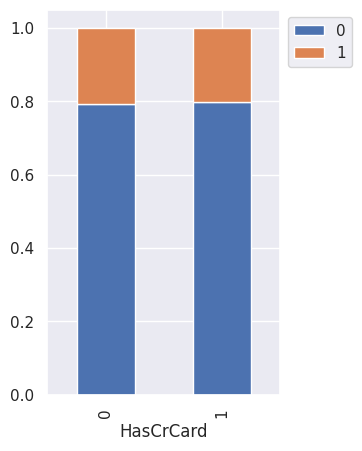

In [0]:
# Visualize the distribution of 'HascrCard' across different 'Exited' categories
stacked_barplot(data, "HasCrCard", "Exited")

- No effect of CreditCard status on Churn, need to explore it with combination of other columns

Exited             0     1    All
IsActiveMember                   
All             7963  2037  10000
0               3547  1302   4849
1               4416   735   5151
------------------------------------------------------------------------------------------------------------------------


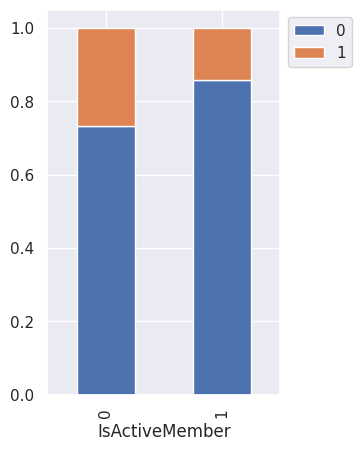

In [0]:
# Visualize the distribution of 'IsActiveMember' across different 'Exited' categories
stacked_barplot(data, "IsActiveMember", "Exited")

- Inactive members are likely to churn more

Exited           0     1   All
BalanceGroup                  
All           7963  2036  9999
100k–150k     2843   987  3830
Zero          3117   500  3617
50k–100k      1209   300  1509
150k–200k      730   205   935
1–50k           49    26    75
200k–250k       15    18    33
------------------------------------------------------------------------------------------------------------------------


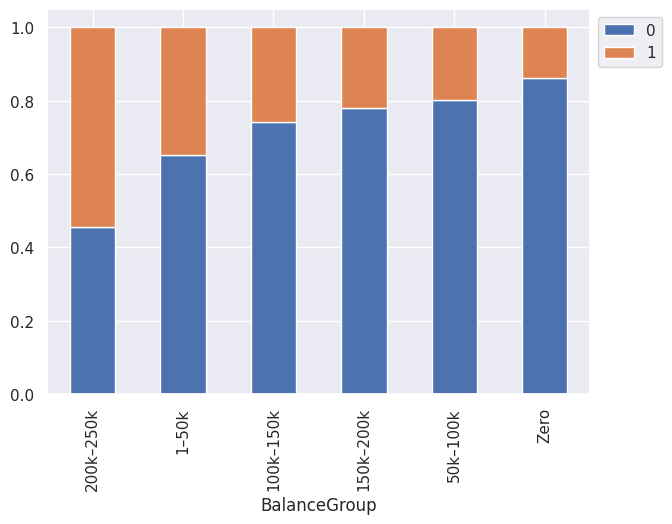

In [0]:
# Visualize the distribution of 'Balance' across different 'Exited' categories

# Create Balance bins
bins = [0, 1, 50000, 100000, 150000, 200000, 250000]
labels = ["Zero", "1–50k", "50k–100k", "100k–150k", "150k–200k", "200k–250k"]

df["BalanceGroup"] = pd.cut(data["Balance"], bins=bins, labels=labels, include_lowest=True)

# Now plot churn distribution by Balance group
stacked_barplot(df, "BalanceGroup", "Exited")


- Zero-balance customers churn less, even though they are a big segment
- Mid-to-high balances (50k–200k, especially 100k–150k) show higher churn rates
- Very low (1–50k) and very high (200k+) balances show churn, but group sizes are too small for solid conclusions

Exited          0     1    All
SalaryGroup                   
All          7963  2037  10000
160k–180k     784   225   1009
60k–80k       815   212   1027
100k–120k     816   211   1027
140k–160k     776   206    982
180k–200k     779   206    985
0–20k         788   198    986
120k–140k     811   196   1007
20k–40k       773   196    969
80k–100k      806   196   1002
40k–60k       815   191   1006
------------------------------------------------------------------------------------------------------------------------


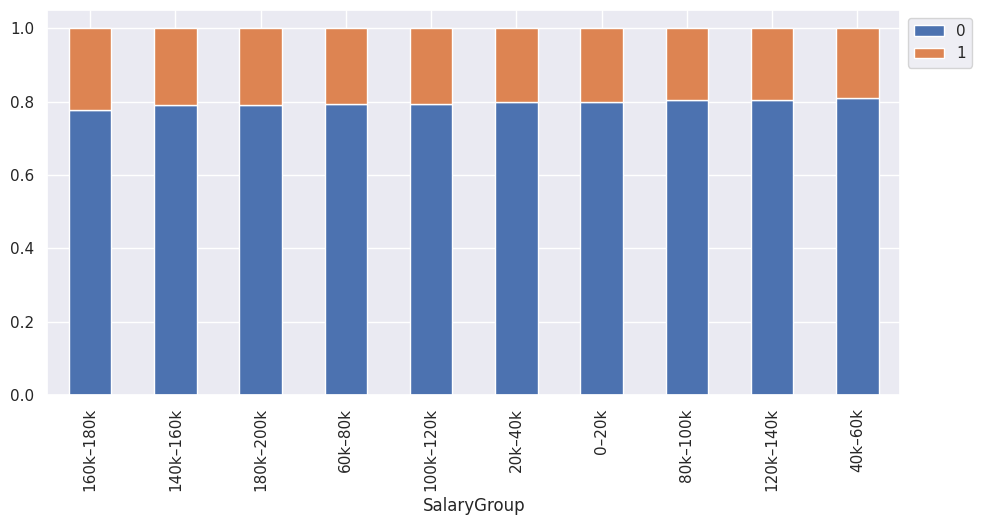

In [0]:
# Create salary bins
bins = [0, 20000, 40000, 60000, 80000, 100000, 120000, 140000, 160000, 180000, 200000]
labels = [
    "0–20k", "20k–40k", "40k–60k", "60k–80k", "80k–100k",
    "100k–120k", "120k–140k", "140k–160k", "160k–180k", "180k–200k"
]

df["SalaryGroup"] = pd.cut(data["EstimatedSalary"], bins=bins, labels=labels, include_lowest=True)

# Plot churn distribution by salary group
stacked_barplot(df, "SalaryGroup", "Exited")

- No clear relationship between estimated salary and likelihood of churn

## Data Preprocessing

**Split the data in train, validation and test data**

In [0]:
# creating the copy of the dataframe
df1 = data.copy()

In [0]:
## Storing required categorical variables in cat_dat to apply dummification
cat_data = ["Gender",'Geography']

In [0]:
X = df1.drop(["Exited"], axis=1)
y = df1["Exited"]

print(X.shape)
print(y.shape)
print(type(X))

(10000, 10)
(10000,)
<class 'pandas.core.frame.DataFrame'>


In [0]:
y.unique()

array([1, 0])

In [0]:
# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, shuffle=True
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, shuffle=True
)
print(X_train.shape, X_val.shape, X_test.shape)

(6000, 10) (2000, 10) (2000, 10)


In [0]:
X_train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
4495,789,France,Female,32,7,69423.52,1,1,0,107499.39
6470,583,Germany,Female,41,5,77647.60,1,1,0,190429.52
2221,767,Germany,Female,35,6,132253.22,1,1,0,115566.57
7686,718,France,Male,48,9,0.00,2,1,1,72105.63
9419,686,Germany,Male,26,1,57422.62,1,1,1,79189.40


**Normalizing**

In [0]:
## Scaling the data
sc=StandardScaler()
temp = sc.fit(X_train[["CreditScore","Age","Tenure","Balance","EstimatedSalary"]])
X_train[["CreditScore","Age","Tenure","Balance","EstimatedSalary"]] = temp.transform(X_train[["CreditScore","Age","Tenure","Balance","EstimatedSalary"]])
X_test[["CreditScore","Age","Tenure","Balance","EstimatedSalary"]] = temp.transform(X_test[["CreditScore","Age","Tenure","Balance","EstimatedSalary"]])
X_val[["CreditScore","Age","Tenure","Balance","EstimatedSalary"]] = temp.transform(X_val[["CreditScore","Age","Tenure","Balance","EstimatedSalary"]])

In Binary classification, no need of scaling the target variable

**Categorical Encoding**

In [0]:
# Using pd.get dummies to encode the categorical columns in the data
X_train = pd.get_dummies(X_train,columns=cat_data,drop_first= True)
X_test = pd.get_dummies(X_test,columns=cat_data,drop_first= True)
X_val = pd.get_dummies(X_val,columns=cat_data,drop_first= True)

In [0]:
# Checking the shape
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(6000, 11)
(2000, 11)
(6000,)
(2000,)
(2000, 11)
(2000,)


## Model Building

#### Utility Functions for Metrics

In [0]:
def make_confusion_matrix(cf,
                          group_names=None,
                          categories='auto',
                          count=True,
                          percent=True,
                          cbar=True,
                          xyticks=True,
                          xyplotlabels=True,
                          sum_stats=True,
                          figsize=None,
                          cmap='Blues',
                          title=None):
    '''
    This function will make a pretty plot of an sklearn Confusion Matrix cm using a Seaborn heatmap visualization.
    Arguments
    '''


    # CODE TO GENERATE TEXT INSIDE EACH SQUARE
    blanks = ['' for i in range(cf.size)]

    if group_names and len(group_names)==cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.0f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        group_percentages = ["{0:.2%}".format(value) for value in cf.flatten()/np.sum(cf)]
    else:
        group_percentages = blanks

    box_labels = [f"{v1}{v2}{v3}".strip() for v1, v2, v3 in zip(group_labels,group_counts,group_percentages)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])


    # CODE TO GENERATE SUMMARY STATISTICS & TEXT FOR SUMMARY STATS
    if sum_stats:
        #Accuracy is sum of diagonal divided by total observations
        accuracy  = np.trace(cf) / float(np.sum(cf))



    # SET FIGURE PARAMETERS ACCORDING TO OTHER ARGUMENTS
    if figsize==None:
        #Get default figure size if not set
        figsize = plt.rcParams.get('figure.figsize')

    if xyticks==False:
        #Do not show categories if xyticks is False
        categories=False


    # MAKE THE HEATMAP VISUALIZATION
    plt.figure(figsize=figsize)
    sns.heatmap(cf,annot=box_labels,fmt="",cmap=cmap,cbar=cbar,xticklabels=categories,yticklabels=categories)


    if title:
        plt.title(title)

In [0]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def gmean_score(y_true, y_pred):
    rec0 = recall_score(y_true, y_pred, pos_label=0)
    rec1 = recall_score(y_true, y_pred, pos_label=1)
    return np.sqrt(rec0 * rec1)

def evaluate_model(name, y_true, y_prob, threshold=0.5, results_df=None):
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    gmean = gmean_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)

    print(f"=== {name} ===")
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}, AUC: {auc:.3f}, G-mean: {gmean:.3f}")
    print("")

    if results_df is not None:
        results_df.loc[len(results_df)] = [name, acc, prec, rec, f1, auc, gmean]
    return results_df

# Create empty results DataFrame
import pandas as pd
results_df = pd.DataFrame(columns=["Model","Accuracy","Precision","Recall","F1","AUC","G-mean"])

In [0]:
# Defining Early stopping
es_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0.001, patience=5)

#### Model 0 — Baseline (SGD Optimizer)
- SGD (Stochastic Gradient Descent) as optimizer

In [0]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

In [0]:
# Initializing the ANN
model_SGD = Sequential()
# The amount of nodes (dimensions) in hidden layer should be the average of input and output layers, in this case 64.
# This adds the input layer (by specifying input dimension) AND the first hidden layer (units)
model_SGD.add(Dense(activation = 'relu', input_dim = 11, units=64))
#Adding 1st hidden layer
model_SGD.add(Dense(32, activation='relu'))
# Adding the output layer
model_SGD.add(Dense(1, activation = 'sigmoid'))

/local_disk0/.ephemeral_nfs/envs/pythonEnv-a5a4c5ef-4973-4bd2-937a-50ee1efd1839/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-09-21 16:18:21.997216: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [0]:
# Create optimizer with default learning rate
model_SGD.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])

In [0]:
# Model summary
model_SGD.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [0]:
history_SGD=model_SGD.fit(X_train, y_train,
          validation_data=(X_val,y_val),
          epochs=50,
          batch_size=32,verbose=1)

Epoch 1/50
179/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7442 - loss: 0.5818

188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7875 - loss: 0.5283 - val_accuracy: 0.7925 - val_loss: 0.4895
Epoch 2/50
163/188 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7868 - loss: 0.4906

188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7988 - loss: 0.4702 - val_accuracy: 0.7925 - val_loss: 0.4681
Epoch 3/50
183/188 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7880 - loss: 0.4694 

188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7985 - loss: 0.4520 - val_accuracy: 0.7905 - val_loss: 0.4555
Epoch 4/50
186/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7896 - loss: 0.4573

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7983 - loss: 0.4412 - val_accuracy: 0.7895 - val_loss: 0.4483
Epoch 5/50
186/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7906 - loss: 0.4503

...

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8415 - loss: 0.3815 - val_accuracy: 0.8270 - val_loss: 0.4073
Epoch 48/50
157/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8362 - loss: 0.3935

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8422 - loss: 0.3805 - val_accuracy: 0.8265 - val_loss: 0.4066
Epoch 49/50
186/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8377 - loss: 0.3906

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8428 - loss: 0.3795 - val_accuracy: 0.8270 - val_loss: 0.4060
Epoch 50/50
158/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8374 - loss: 0.3912

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8435 - loss: 0.3785 - val_accuracy: 0.8285 - val_loss: 0.4054


🏃 View run respected-newt-752 at: https://adb-6722499136019472.12.azuredatabricks.net/ml/experiments/3222707499942634/runs/de01938d7dfe403cb1d5d5ead6d0e122
🧪 View experiment at: https://adb-6722499136019472.12.azuredatabricks.net/ml/experiments/3222707499942634


In [0]:
# Get predicted probabilities
y_prob_sgd = model_SGD.predict(X_test).ravel()

# Evaluate and log results (threshold = 0.5 by default)
results_df = evaluate_model("Model 0 — SGD", y_test, y_prob_sgd, threshold=0.5, results_df=results_df)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
=== Model 0 — SGD ===
Confusion Matrix:
 [[1547   38]
 [ 274  141]]
Accuracy: 0.844, Precision: 0.788, Recall: 0.340, F1: 0.475, AUC: 0.829, G-mean: 0.576



**Loss function**

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8440 - loss: 0.3810


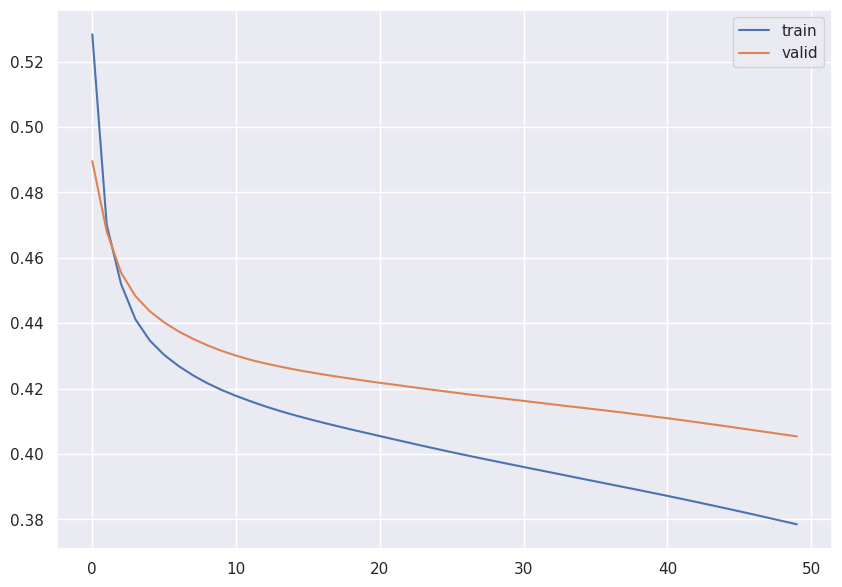

In [0]:
# Capturing learning history per epoch
hist  = pd.DataFrame(history_SGD.history)
hist['epoch'] = history_SGD.epoch

# Plotting accuracy at different epochs
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.legend(("train" , "valid") , loc =0)

#Printing results
results = model_SGD.evaluate(X_test, y_test)

The validation data is performing well respect the training data. Anyhow, the model tends to overfit.

Let's check the other metrices.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Best Threshold=0.175682, G-Mean=0.754


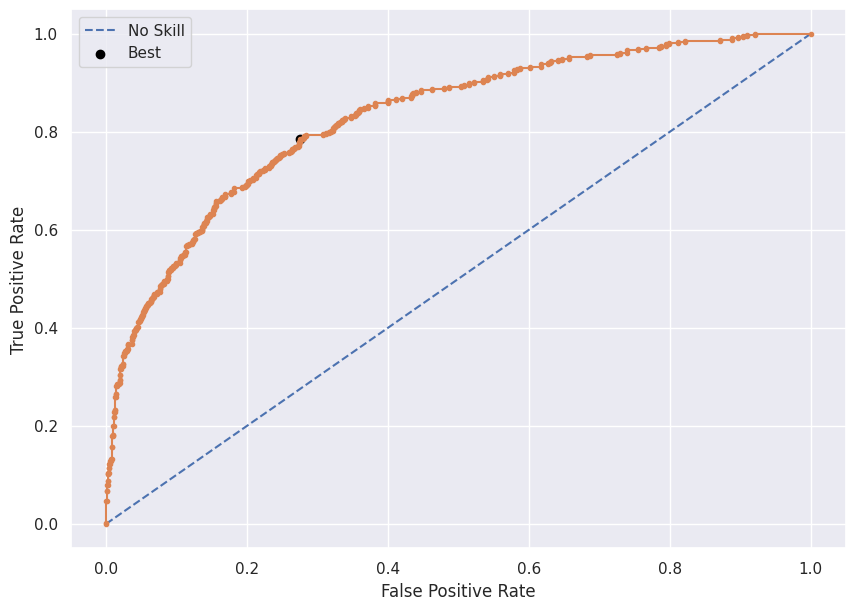

In [0]:
from sklearn.metrics import roc_curve
from matplotlib import pyplot

# predict probabilities
yhat_SGD = model_SGD.predict(X_test)
# keep probabilities for the positive outcome only
yhat_SGD = yhat_SGD[:, 0]
# calculate roc curves
fpr, tpr, thresholds_SGD = roc_curve(y_test, yhat_SGD)
# calculate the g-mean for each threshold
gmeans_SGD = np.sqrt(tpr * (1-fpr))
# locate the index of the largest g-mean
ix = np.argmax(gmeans_SGD)
print('Best Threshold=%f, G-Mean=%.3f' % (thresholds_SGD[ix], gmeans_SGD[ix]))
# plot the roc curve for the model
pyplot.plot([0,1], [0,1], linestyle='--', label='No Skill')
pyplot.plot(fpr, tpr, marker='.')
pyplot.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best')

pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()

pyplot.show()

**Confusion matrix**

In [0]:
y_pred_SGD=model_SGD.predict(X_test)
y_pred_SGD = (y_pred_SGD > thresholds_SGD[ix])
y_pred_SGD

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[False],
       [False],
       [ True],
       ...,
       [False],
       [False],
       [ True]])

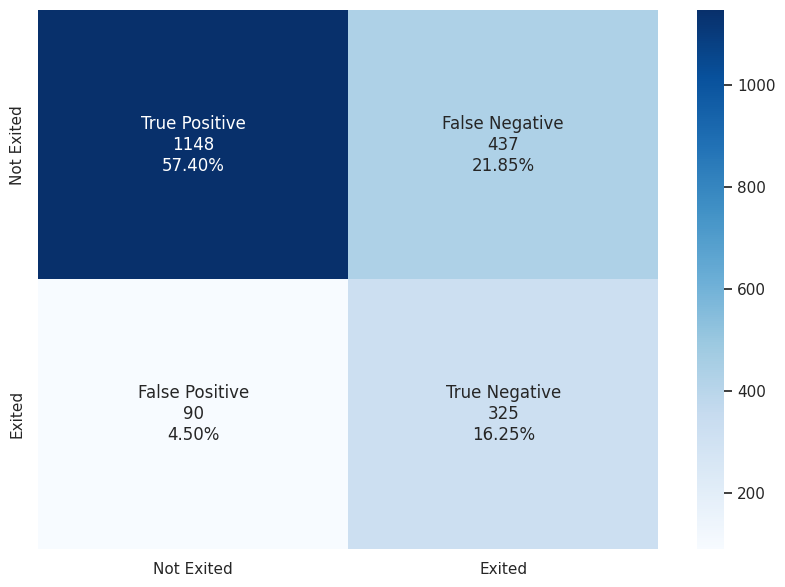

In [0]:
#Calculating the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm_SGD=confusion_matrix(y_test, y_pred_SGD)
labels = ['True Positive','False Negative','False Positive','True Negative']
categories = [ 'Not Exited','Exited']
make_confusion_matrix(cm_SGD,
                      group_names=labels,
                      categories=categories,
                      cmap='Blues')


In [0]:
#Accuracy as per the classification report
from sklearn import metrics
cr_SGD=metrics.classification_report(y_test,y_pred_SGD)
print(cr_SGD)

              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1585
           1       0.43      0.78      0.55       415

    accuracy                           0.74      2000
   macro avg       0.68      0.75      0.68      2000
weighted avg       0.82      0.74      0.76      2000



The above model has:
- A recall of 0.74 for class 0

#### Model 1 — Adam Optimizer

In [0]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

In [0]:
# Initializing the ANN
model_ADAM = Sequential()
# The amount of nodes (dimensions) in hidden layer should be the average of input and output layers, in this case 64.
# This adds the input layer (by specifying input dimension) AND the first hidden layer (units)
model_ADAM.add(Dense(activation = 'relu', input_dim = 11, units=64))
#Add 1st hidden layer
model_ADAM.add(Dense(32, activation='relu'))
# Adding the output layer
# Notice that we do not need to specify input dim.
# we have an output of 1 node, which is the the desired dimensions of our output (stay with the bank or not)
# We use the sigmoid because we want probability outcomes
model_ADAM.add(Dense(1, activation = 'sigmoid'))
      #Compiling the ANN with Adam optimizer and binary cross entropy loss function
optimizer = tf.keras.optimizers.Adam(0.001)
model_ADAM.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=['accuracy'])

/local_disk0/.ephemeral_nfs/envs/pythonEnv-a5a4c5ef-4973-4bd2-937a-50ee1efd1839/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [0]:
model_ADAM.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [0]:
history_ADAM=model_ADAM.fit(X_train, y_train,
          validation_data=(X_val,y_val),
          epochs=50,
          batch_size=32,verbose=1)

Epoch 1/50
172/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7559 - loss: 0.5235

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7953 - loss: 0.4588 - val_accuracy: 0.8055 - val_loss: 0.4358
Epoch 2/50
182/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8143 - loss: 0.4331

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8237 - loss: 0.4153 - val_accuracy: 0.8240 - val_loss: 0.4215
Epoch 3/50
184/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8252 - loss: 0.4121

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8322 - loss: 0.3976 - val_accuracy: 0.8210 - val_loss: 0.4117
Epoch 4/50
182/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8362 - loss: 0.3929

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8405 - loss: 0.3811 - val_accuracy: 0.8235 - val_loss: 0.4044
Epoch 5/50
181/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8420 - loss: 0.3779

...

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8622 - loss: 0.3366 - val_accuracy: 0.8405 - val_loss: 0.3858
Epoch 10/50
181/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8647 - loss: 0.3364

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8652 - loss: 0.3315 - val_accuracy: 0.8410 - val_loss: 0.3846
Epoch 11/50
183/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8655 - loss: 0.3316

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8657 - loss: 0.3272 - val_accuracy: 0.8395 - val_loss: 0.3844
Epoch 12/50
179/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8672 - loss: 0.3276

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8670 - loss: 0.3236 - val_accuracy: 0.8395 - val_loss: 0.3842
Epoch 13/50
178/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8677 - loss: 0.3243

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8680 - loss: 0.3207 - val_accuracy: 0.8380 - val_loss: 0.3835
Epoch 14/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8685 - loss: 0.3182 - val_accuracy: 0.8370 - val_loss: 0.3838
Epoch 15/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8697 - loss: 0.3162 - val_accuracy: 0.8385 - val_loss: 0.3842
Epoch 16/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8710 - loss: 0.3143 - val_accuracy: 0.8365 - val_loss: 0.3847
Epoch 17/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8713 - loss: 0.3126 - val_accuracy: 0.8375 - val_loss: 0.3850
Epoch 18/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8715 - loss: 0.3111 - val_accuracy: 0.8395 - val_loss: 0.3855
Epoch 19/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8725 - loss: 0.3098 - val_accuracy: 0.8385 - val_loss: 0.3860
Epoch 20/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8740 - loss: 0.3085 - val_accuracy: 0.8405

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8510 - loss: 0.3536


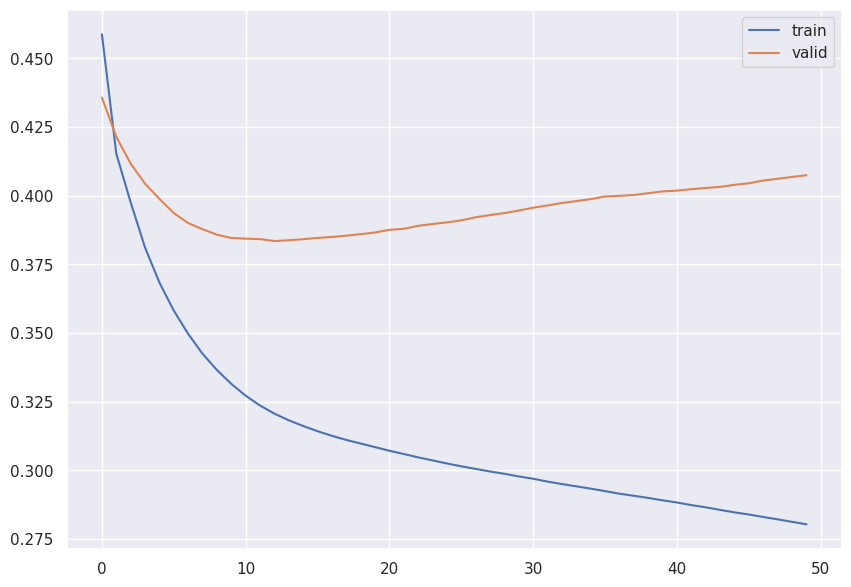

In [0]:
# Capturing learning history per epoch
hist  = pd.DataFrame(history_ADAM.history)
hist['epoch'] = history_ADAM.epoch

# Plotting accuracy at different epochs
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.legend(("train" , "valid") , loc =0)

#Printing results
results = model_ADAM.evaluate(X_test, y_test)

Here the model seems to be overfitted, as the distance between the train curve and validation curved started increasing.
The earlystop function will be used

In [0]:
# Initializing the ANN
model_ADAM_es = Sequential()
model_ADAM_es.add(Dense(activation = 'relu', input_dim = 11, units=64))
#Add 1st hidden layer
model_ADAM_es.add(Dense(32, activation='relu'))
# We use the sigmoid because we want probability outcomes
model_ADAM_es.add(Dense(1, activation = 'sigmoid'))
      #Compiling the ANN with Adam optimizer and binary cross entropy loss function
optimizer = tf.keras.optimizers.Adam(0.001)
model_ADAM_es.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=['accuracy'])

/local_disk0/.ephemeral_nfs/envs/pythonEnv-a5a4c5ef-4973-4bd2-937a-50ee1efd1839/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [0]:
history_ADAM_es=model_ADAM_es.fit(X_train, y_train,
          validation_data=(X_val,y_val),
          epochs=50,
          batch_size=32,verbose=1, callbacks=[es_cb])

Epoch 1/50
170/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7113 - loss: 0.5460

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7863 - loss: 0.4662 - val_accuracy: 0.8090 - val_loss: 0.4325
Epoch 2/50
183/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8143 - loss: 0.4295

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8222 - loss: 0.4146 - val_accuracy: 0.8170 - val_loss: 0.4245
Epoch 3/50
173/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8247 - loss: 0.4160

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8305 - loss: 0.4009 - val_accuracy: 0.8240 - val_loss: 0.4182
Epoch 4/50
174/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8312 - loss: 0.4014

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8353 - loss: 0.3875 - val_accuracy: 0.8285 - val_loss: 0.4109
Epoch 5/50
176/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8388 - loss: 0.3865

...

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8588 - loss: 0.3323 - val_accuracy: 0.8395 - val_loss: 0.3857
Epoch 12/50
177/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8604 - loss: 0.3336

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8623 - loss: 0.3284 - val_accuracy: 0.8385 - val_loss: 0.3845
Epoch 13/50
179/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8612 - loss: 0.3297

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8630 - loss: 0.3250 - val_accuracy: 0.8380 - val_loss: 0.3835
Epoch 14/50
164/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8626 - loss: 0.3266

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8650 - loss: 0.3220 - val_accuracy: 0.8350 - val_loss: 0.3833
Epoch 15/50
179/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8626 - loss: 0.3235

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8652 - loss: 0.3194 - val_accuracy: 0.8350 - val_loss: 0.3824
Epoch 16/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8670 - loss: 0.3170 - val_accuracy: 0.8350 - val_loss: 0.3825
Epoch 17/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8675 - loss: 0.3148 - val_accuracy: 0.8355 - val_loss: 0.3827
Epoch 18/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8683 - loss: 0.3126 - val_accuracy: 0.8330 - val_loss: 0.3831
Epoch 19/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8695 - loss: 0.3109 - val_accuracy: 0.8350 - val_loss: 0.3836
Epoch 20/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8692 - loss: 0.3092 - val_accuracy: 0.8360 - val_loss: 0.3840
🏃 View run learned-bear-290 at: https://adb-6722499136019472.12.azuredatabricks.net/ml/experiments/3222707499942634/runs/6ae6a65cc82c4f5e91ebb4254c8ba2a1
🧪 View experiment at: https://adb-6722499136019472.12.azuredatabricks.net/ml/experim

In [0]:
y_prob_adam = model_ADAM.predict(X_test).ravel()
results_df = evaluate_model("Model 1 — Adam", y_test, y_prob_adam, threshold=0.5, results_df=results_df)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
=== Model 1 — Adam ===
Confusion Matrix:
 [[1491   94]
 [ 204  211]]
Accuracy: 0.851, Precision: 0.692, Recall: 0.508, F1: 0.586, AUC: 0.856, G-mean: 0.692



63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8640 - loss: 0.3325


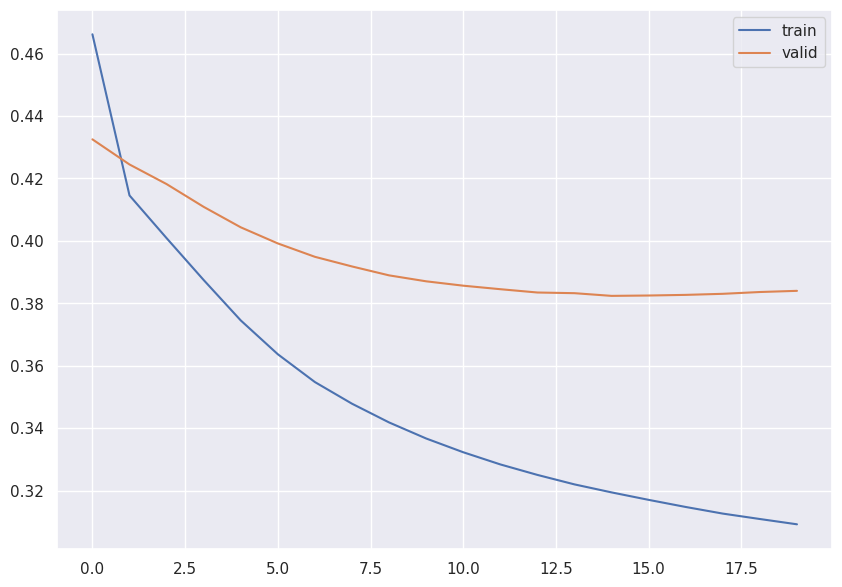

In [0]:
# Capturing learning history per epoch
hist  = pd.DataFrame(history_ADAM_es.history)
hist['epoch'] = history_ADAM_es.epoch

# Plotting accuracy at different epochs
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.legend(("train" , "valid") , loc =0)

#Printing results
results = model_ADAM_es.evaluate(X_test, y_test)

Even using earlystop to prevent overfitting the train and valid curves tend to overfit.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Best Threshold=0.258540, G-Mean=0.785


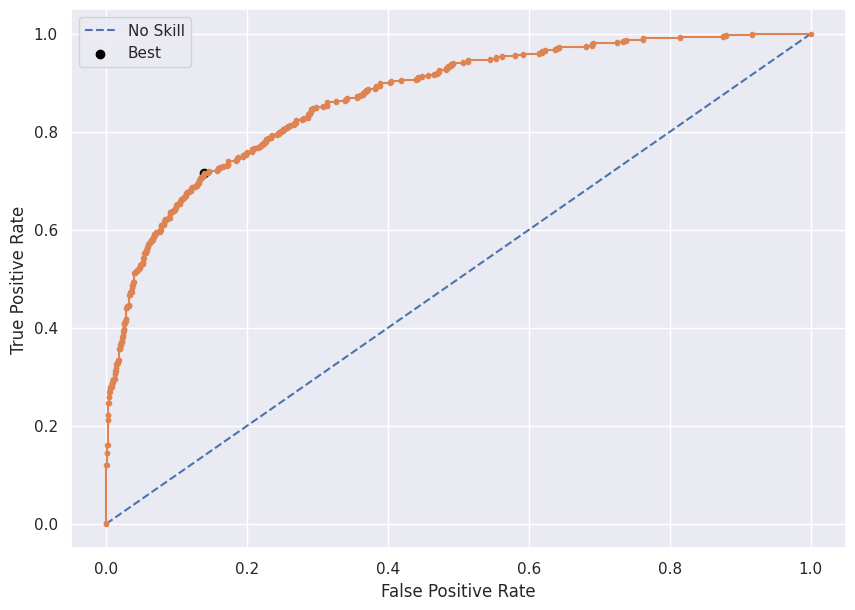

In [0]:
from sklearn.metrics import roc_curve

from matplotlib import pyplot


# predict probabilities
yhat_ADAM = model_ADAM_es.predict(X_test)
# keep probabilities for the positive outcome only
yhat_ADAM = yhat_ADAM[:, 0]
# calculate roc curves
fpr, tpr, thresholds_ADAM = roc_curve(y_test, yhat_ADAM)
# calculate the g-mean for each threshold
gmeans_ADAM = np.sqrt(tpr * (1-fpr))
# locate the index of the largest g-mean
ix = np.argmax(gmeans_ADAM)
print('Best Threshold=%f, G-Mean=%.3f' % (thresholds_ADAM[ix], gmeans_ADAM[ix]))
# plot the roc curve for the model
pyplot.plot([0,1], [0,1], linestyle='--', label='No Skill')
pyplot.plot(fpr, tpr, marker='.')
pyplot.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()
# show the plot
pyplot.show()

In [0]:
#Predicting the results using best as a threshold
y_pred_ADAM=model_ADAM_es.predict(X_test)
y_pred_ADAM = (y_pred_ADAM > thresholds_ADAM[ix])
y_pred_ADAM

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [ True]])

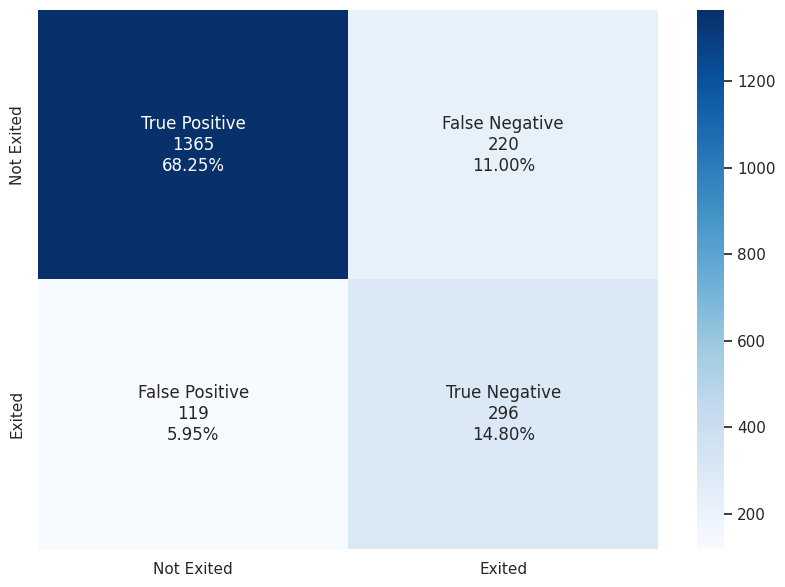

In [0]:
#Calculating the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm_ADAM=confusion_matrix(y_test, y_pred_ADAM)
labels = ['True Positive','False Negative','False Positive','True Negative']
categories = [ 'Not Exited','Exited']
make_confusion_matrix(cm_ADAM,
                      group_names=labels,
                      categories=categories,
                      cmap='Blues')

The false positives got a reduction but the percentage of true positives is less than the percentage obtained for SGD model training.  

In [0]:
#Accuracy as per the classification report
from sklearn import metrics
cr_ADAM=metrics.classification_report(y_test,y_pred_ADAM)
print(cr_ADAM)

              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1585
           1       0.57      0.71      0.64       415

    accuracy                           0.83      2000
   macro avg       0.75      0.79      0.76      2000
weighted avg       0.85      0.83      0.84      2000



The Adam optimizer model has:
- A recall of 0.81 for class 0

#### Model 2 — Dropout + Adam

In [0]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

In [0]:
# Initializing the ANN
model_DOUT = Sequential()
# The amount of nodes (dimensions) in hidden layer should be the average of input and output layers, in this case 64.
# This adds the input layer (by specifying input dimension) AND the first hidden layer (units)
model_DOUT.add(Dense(activation = 'relu', input_dim = 11, units=64))
model_DOUT.add(Dropout(0.2))
#Add 1st hidden layer
model_DOUT.add(Dense(32, activation='relu'))
model_DOUT.add(Dropout(0.2))
# Adding the output layer
# Notice that we do not need to specify input dim.
# we have an output of 1 node, which is the the desired dimensions of our output (stay with the bank or not)
# We use the sigmoid because we want probability outcomes
model_DOUT.add(Dense(1, activation = 'sigmoid'))
      #Compiling the ANN with Adam optimizer and binary cross entropy loss function
optimizer = tf.keras.optimizers.Adam(0.001)
model_DOUT.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=['accuracy'])

/local_disk0/.ephemeral_nfs/envs/pythonEnv-a5a4c5ef-4973-4bd2-937a-50ee1efd1839/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [0]:
model_DOUT.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [0]:
history_DOUT=model_DOUT.fit(X_train, y_train,
          validation_data=(X_val,y_val),
          epochs=50,
          batch_size=32,verbose=1)

Epoch 1/50
162/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7291 - loss: 0.5484

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7863 - loss: 0.4737 - val_accuracy: 0.8025 - val_loss: 0.4370
Epoch 2/50
168/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8068 - loss: 0.4539

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8138 - loss: 0.4331 - val_accuracy: 0.8090 - val_loss: 0.4265
Epoch 3/50
169/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8127 - loss: 0.4392

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8190 - loss: 0.4209 - val_accuracy: 0.8185 - val_loss: 0.4214
Epoch 4/50
167/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8190 - loss: 0.4311

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8257 - loss: 0.4166 - val_accuracy: 0.8185 - val_loss: 0.4167
Epoch 5/50
170/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8290 - loss: 0.4216

...

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8627 - loss: 0.3374 - val_accuracy: 0.8450 - val_loss: 0.3720
Epoch 25/50
170/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8621 - loss: 0.3406

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8637 - loss: 0.3364 - val_accuracy: 0.8420 - val_loss: 0.3717
Epoch 26/50
173/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8625 - loss: 0.3392

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8632 - loss: 0.3324 - val_accuracy: 0.8455 - val_loss: 0.3707
Epoch 27/50
172/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8626 - loss: 0.3373

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8638 - loss: 0.3311 - val_accuracy: 0.8440 - val_loss: 0.3689
Epoch 28/50
167/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8634 - loss: 0.3323

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8652 - loss: 0.3312 - val_accuracy: 0.8440 - val_loss: 0.3686
Epoch 29/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8632 - loss: 0.3274 - val_accuracy: 0.8460 - val_loss: 0.3687
Epoch 30/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8682 - loss: 0.3294 - val_accuracy: 0.8430 - val_loss: 0.3689
Epoch 31/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8660 - loss: 0.3272 - val_accuracy: 0.8455 - val_loss: 0.3694
Epoch 32/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8687 - loss: 0.3282 - val_accuracy: 0.8425 - val_loss: 0.3703
Epoch 33/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8670 - loss: 0.3247 - val_accuracy: 0.8445 - val_loss: 0.3713
Epoch 34/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8660 - loss: 0.3292 - val_accuracy: 0.8435 - val_loss: 0.3730
Epoch 35/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8690 - loss: 0.3229 - val_accuracy: 0.8460

In [0]:
y_prob_drop = model_DOUT.predict(X_test).ravel()
results_df = evaluate_model("Model 2 — Dropout+Adam", y_test, y_prob_drop, threshold=0.5, results_df=results_df)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
=== Model 2 — Dropout+Adam ===
Confusion Matrix:
 [[1534   51]
 [ 207  208]]
Accuracy: 0.871, Precision: 0.803, Recall: 0.501, F1: 0.617, AUC: 0.872, G-mean: 0.696



63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8710 - loss: 0.3280


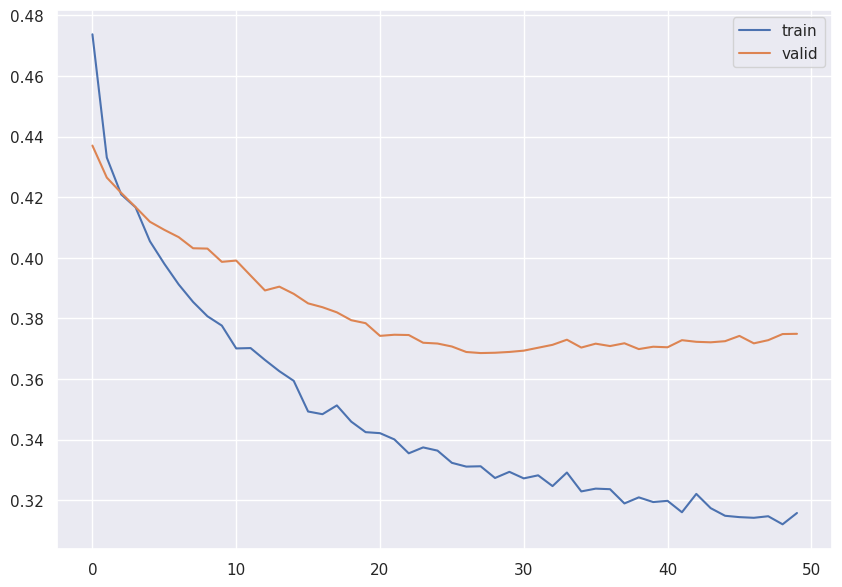

In [0]:
# Capturing learning history per epoch
hist  = pd.DataFrame(history_DOUT.history)
hist['epoch'] = history_DOUT.epoch

# Plotting accuracy at different epochs
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.legend(("train" , "valid") , loc =0)

#Printing results
results = model_DOUT.evaluate(X_test, y_test)

Here the model seems to be overfitted, as the distance between the train curve and validation curved started increasing.
The earlystop function will be used

In [0]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

In [0]:
# Initializing the ANN and adding dropout ratio of 0.2
model_DOUT_es = Sequential()
model_DOUT_es.add(Dense(activation = 'relu', input_dim = 11, units=64))
model_DOUT_es.add(Dropout(0.2))
#Add 1st hidden layer
model_DOUT_es.add(Dense(32, activation='relu'))
model_DOUT_es.add(Dropout(0.2))
# Adding the output layer
model_DOUT_es.add(Dense(1, activation = 'sigmoid'))
      #Compiling the ANN with Adam optimizer and binary cross entropy loss function
optimizer = tf.keras.optimizers.Adam(0.001)
model_DOUT_es.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=['accuracy'])

/local_disk0/.ephemeral_nfs/envs/pythonEnv-a5a4c5ef-4973-4bd2-937a-50ee1efd1839/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [0]:
history_DOUT_es=model_DOUT_es.fit(X_train, y_train,
          validation_data=(X_val,y_val),
          epochs=50,
          batch_size=32,verbose=1, callbacks=[es_cb])

Epoch 1/50
187/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7398 - loss: 0.5448

188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7882 - loss: 0.4816 - val_accuracy: 0.8055 - val_loss: 0.4403
Epoch 2/50
168/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8001 - loss: 0.4500

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8108 - loss: 0.4344 - val_accuracy: 0.8175 - val_loss: 0.4305
Epoch 3/50
163/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8135 - loss: 0.4403

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8232 - loss: 0.4233 - val_accuracy: 0.8185 - val_loss: 0.4262
Epoch 4/50
165/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8214 - loss: 0.4332

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8288 - loss: 0.4167 - val_accuracy: 0.8205 - val_loss: 0.4204
Epoch 5/50
166/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8234 - loss: 0.4266

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8302 - loss: 0.4082 - val_accuracy: 0.8220 - val_loss: 0.4169
🏃 View run chill-swan-740 at: https://adb-6722499136019472.12.azuredatabricks.net/ml/experiments/3222707499942634/runs/e2593d4fe7794c418cb5b1637ec5fb60
🧪 View experiment at: https://adb-6722499136019472.12.azuredatabricks.net/ml/experiments/3222707499942634


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8400 - loss: 0.3903


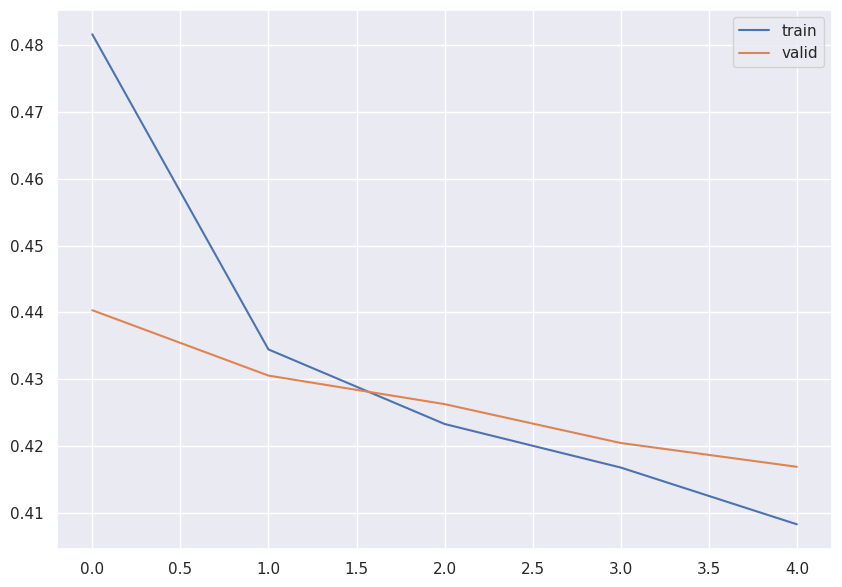

In [0]:
# Capturing learning history per epoch
hist  = pd.DataFrame(history_DOUT_es.history)
hist['epoch'] = history_DOUT_es.epoch

# Plotting accuracy at different epochs
plt.plot(hist['loss'])
plt.plot(hist['val_loss'])
plt.legend(("train" , "valid") , loc =0)

#Printing results
results = model_DOUT_es.evaluate(X_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Best Threshold=0.193988, G-Mean=0.750


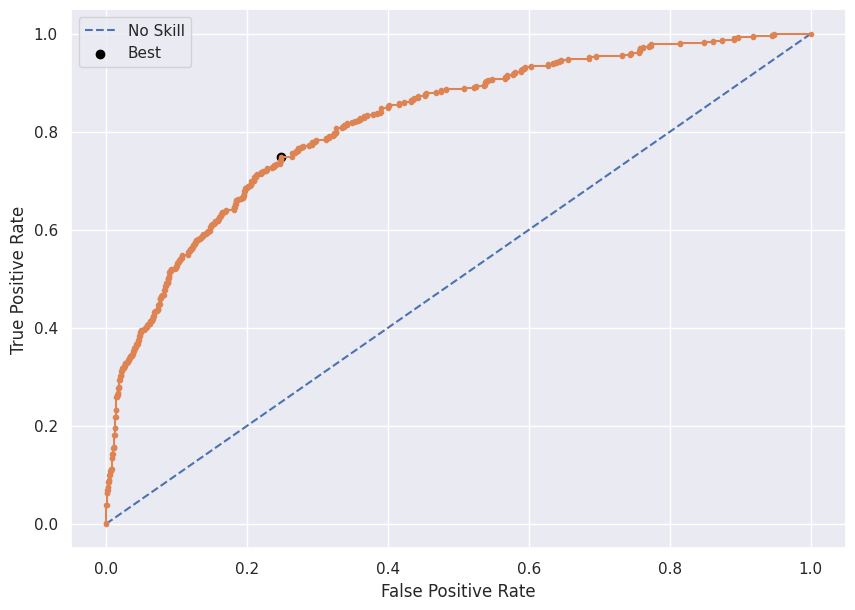

In [0]:
# predict probabilities
yhat_DOUT = model_DOUT_es.predict(X_test)
# keep probabilities for the positive outcome only
yhat_DOUT = yhat_DOUT[:, 0]
# calculate roc curves
fpr, tpr, thresholds_DOUT = roc_curve(y_test, yhat_DOUT)
# calculate the g-mean for each threshold
gmeans_DOUT = np.sqrt(tpr * (1-fpr))
# locate the index of the largest g-mean
ix = np.argmax(gmeans_DOUT)
print('Best Threshold=%f, G-Mean=%.3f' % (thresholds_DOUT[ix], gmeans_DOUT[ix]))
# plot the roc curve for the model
pyplot.plot([0,1], [0,1], linestyle='--', label='No Skill')
pyplot.plot(fpr, tpr, marker='.')
pyplot.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()
# show the plot
pyplot.show()

In [0]:
#Predicting the results using best as a threshold
y_pred_DOUT=model_DOUT_es.predict(X_test)
y_pred_DOUT = (y_pred_DOUT > thresholds_DOUT[ix])
y_pred_DOUT

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [ True]])

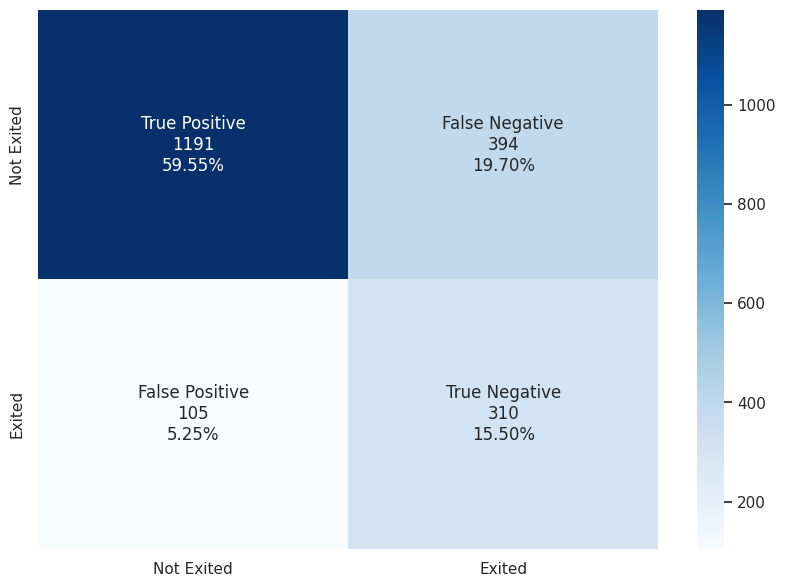

In [0]:
#Calculating the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm_DOUT=confusion_matrix(y_test, y_pred_DOUT)
labels = ['True Positive','False Negative','False Positive','True Negative']
categories = [ 'Not Exited','Exited']
make_confusion_matrix(cm_DOUT,
                      group_names=labels,
                      categories=categories,
                      cmap='Blues')

In [0]:
#Accuracy as per the classification report
from sklearn import metrics
cr_DOUT=metrics.classification_report(y_test,y_pred_DOUT)
print(cr_DOUT)

              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1585
           1       0.44      0.75      0.55       415

    accuracy                           0.75      2000
   macro avg       0.68      0.75      0.69      2000
weighted avg       0.82      0.75      0.77      2000



The Neural Network model with dropout has:
- A recall of 0.78 for class 0

#### Model 3 — Hyperparameter Tuning (RandomSearch + Adam)

We are using Random search to optimize the following hyperparameters:

- **Number of layers**
- **Learning Rate**
- **Units**
- **Dropout**
- The tuning objective is the validation loss "val_accuracy"

In [0]:
backend.clear_session()
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

In [0]:
def build_model(h):
    model = keras.Sequential()
    #let's try 1 to 5 layers
    #let's try units between 32 and 128
    for i in range(h.Int('num_layers', 1, 5)):
        model.add(layers.Dense(units=h.Int('units_' + str(i),
                                            min_value=32,
                                            max_value=128,
                                            step=32),
                               activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    #let's try dropout 0.25
    if h.Boolean("dropout"):
      model.add(layers.Dropout(rate=0.25))
    #let's try learning rate
    model.compile(
        optimizer=keras.optimizers.Adam(
            h.Choice('learning_rate', [1e-1, 1e-2, 1e-3])),
        loss='binary_crossentropy',
        metrics=['accuracy'])
    return model

In [0]:
from kerastuner.tuners import RandomSearch as RandomizedSearch

tuner = RandomizedSearch(
    build_model,
    objective="val_accuracy",
    # Let's use 15 trials
    max_trials=25,
    executions_per_trial=1,
    project_name='Job_',
)
tuner.search_space_summary()

Reloading Tuner from ./Job_/tuner0.json
Search space summary
Default search space size: 8
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 5, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
dropout (Boolean)
{'default': False, 'conditions': []}
learning_rate (Choice)
{'default': 0.1, 'conditions': [], 'values': [0.1, 0.01, 0.001], 'ordered': True}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
units_2 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
units_3 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
units_4 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}


In [0]:
### Searching the best model on X and y train
tuner.search(X_train, y_train,
             epochs=15,
             validation_split = 0.2)

In [0]:
## Printing the best models with their hyperparameters
tuner.results_summary()

Results summary
Results in ./Job_
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 13 summary
Hyperparameters:
num_layers: 2
units_0: 64
dropout: False
learning_rate: 0.01
units_1: 32
units_2: 96
units_3: 64
units_4: 128
Score: 0.8650000095367432

Trial 24 summary
Hyperparameters:
num_layers: 3
units_0: 32
dropout: False
learning_rate: 0.001
units_1: 128
units_2: 96
units_3: 64
units_4: 96
Score: 0.8600000143051147

Trial 09 summary
Hyperparameters:
num_layers: 3
units_0: 32
dropout: False
learning_rate: 0.001
units_1: 96
units_2: 32
units_3: 96
units_4: 96
Score: 0.8583333492279053

Trial 07 summary
Hyperparameters:
num_layers: 5
units_0: 96
dropout: False
learning_rate: 0.001
units_1: 128
units_2: 128
units_3: 128
units_4: 64
Score: 0.8516666889190674

Trial 15 summary
Hyperparameters:
num_layers: 4
units_0: 64
dropout: True
learning_rate: 0.001
units_1: 128
units_2: 96
units_3: 64
units_4: 32
Score: 0.8500000238418579

Trial 20 summary
Hyperparameters:
n

Let's create the a model with the best mentioned configuration:
- Layers = 2
- units_0 = 64
- units_1 = 32
- units_2 = 96
- units_3 = 64
- units_4 = 128
- Dropout = False
- lr = 0.01

In [0]:
backend.clear_session()
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

In [0]:
model_RS = Sequential()
model_RS.add(Dense(64, activation='relu', input_dim=11))  # first hidden layer
model_RS.add(Dense(32, activation='relu'))                # second hidden layer
model_RS.add(Dense(1, activation='sigmoid'))              # output layer

model_RS.summary()

/local_disk0/.ephemeral_nfs/envs/pythonEnv-a5a4c5ef-4973-4bd2-937a-50ee1efd1839/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [0]:
optimizer = tf.keras.optimizers.Adam(0.01)
model_RS.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=['accuracy'])

In [0]:
history_RS = model_RS.fit(X_train,y_train,batch_size=64,epochs=50,verbose=1,validation_data=(X_val,y_val), callbacks=[es_cb])

Epoch 1/50
82/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7705 - loss: 0.4880

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8087 - loss: 0.4339 - val_accuracy: 0.8190 - val_loss: 0.4304
Epoch 2/50
91/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8270 - loss: 0.4134

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8353 - loss: 0.3921 - val_accuracy: 0.8265 - val_loss: 0.4062
Epoch 3/50
88/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8394 - loss: 0.3854

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8457 - loss: 0.3678 - val_accuracy: 0.8345 - val_loss: 0.3938
Epoch 4/50
91/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8538 - loss: 0.3555

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8567 - loss: 0.3457 - val_accuracy: 0.8410 - val_loss: 0.3881
Epoch 5/50
89/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8576 - loss: 0.3425

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8613 - loss: 0.3355 - val_accuracy: 0.8370 - val_loss: 0.3871
🏃 View run nimble-newt-417 at: https://adb-6722499136019472.12.azuredatabricks.net/ml/experiments/3222707499942634/runs/ad0720bba84944ce949e804b7508cda0
🧪 View experiment at: https://adb-6722499136019472.12.azuredatabricks.net/ml/experiments/3222707499942634


In [0]:
y_prob_grid = model_RS.predict(X_test)
results_df = evaluate_model("Model 3 — GridSearch+Adam", y_test, y_prob_grid, threshold=0.5, results_df=results_df)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
=== Model 3 — GridSearch+Adam ===
Confusion Matrix:
 [[1519   66]
 [ 209  206]]
Accuracy: 0.863, Precision: 0.757, Recall: 0.496, F1: 0.600, AUC: 0.860, G-mean: 0.690



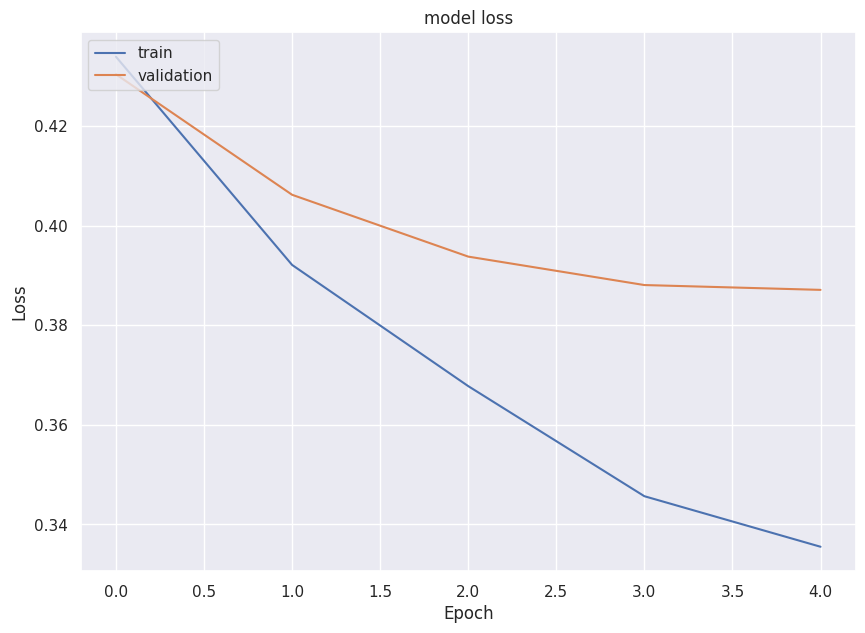

In [0]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_RS.history['loss'])
plt.plot(history_RS.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

There is no to much improvement respect the previous models, and we start to see noise in the model.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Best Threshold=0.224038, G-Mean=0.777


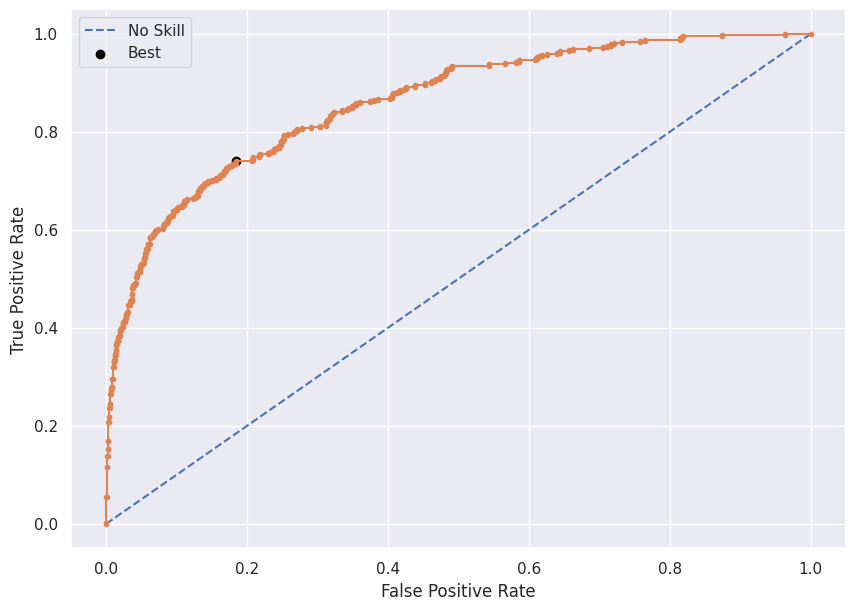

In [0]:
# predict probabilities
yhat_RS = model_RS.predict(X_test)
# keep probabilities for the positive outcome only
yhat_RS = yhat_RS[:, 0]
# calculate roc curves
fpr, tpr, thresholds_RS = roc_curve(y_test, yhat_RS)
# calculate the g-mean for each threshold
gmeans_RS = np.sqrt(tpr * (1-fpr))
# locate the index of the largest g-mean
ix = np.argmax(gmeans_RS)
print('Best Threshold=%f, G-Mean=%.3f' % (thresholds_RS[ix], gmeans_RS[ix]))
# plot the roc curve for the model
pyplot.plot([0,1], [0,1], linestyle='--', label='No Skill')
pyplot.plot(fpr, tpr, marker='.')
pyplot.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()
# show the plot
pyplot.show()

In [0]:
y_pred_RS=model_RS.predict(X_test)
y_pred_RS = (y_pred_RS > thresholds_RS[ix])
y_pred_RS

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [ True]])

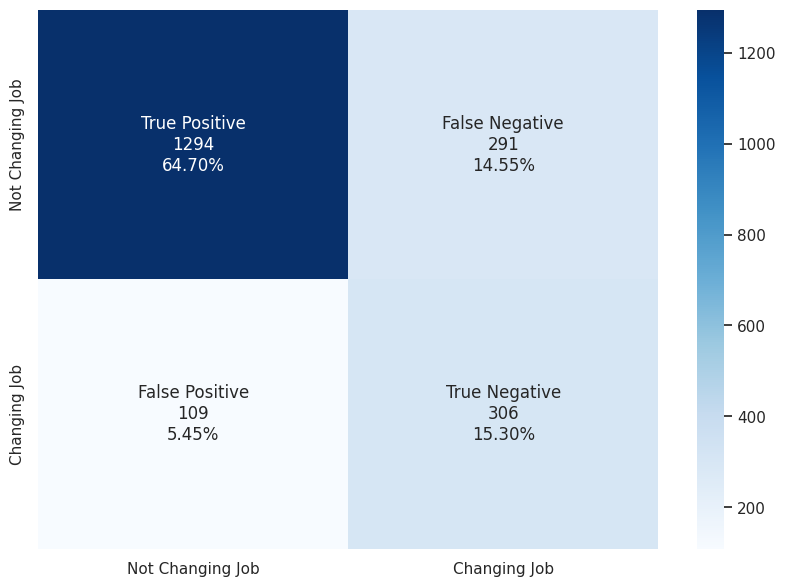

In [0]:
#Calculating the confusion matrix
from sklearn.metrics import confusion_matrix
cm_RS=confusion_matrix(y_test, y_pred_RS)
labels = ['True Positive','False Negative','False Positive','True Negative']
categories = [ 'Not Changing Job','Changing Job']
make_confusion_matrix(cm_RS,
                      group_names=labels,
                      categories=categories,
                      cmap='Blues')

In [0]:
#Accuracy as per the classification report
from sklearn import metrics
cr_RS=metrics.classification_report(y_test,y_pred_RS)
print(cr_RS)

              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1585
           1       0.51      0.74      0.60       415

    accuracy                           0.80      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.80      0.81      2000



The Random Search with Keras tuning model has:
- A recall of 0.74 for class 0

#### Model 4 — SMOTE + Adam

In [0]:
##Applying SMOTE on train and test
from imblearn.over_sampling import SMOTE
smote=SMOTE(sampling_strategy='not majority')
X_sm , y_sm = smote.fit_resample(X_train,y_train)
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))


Before Oversampling, counts of label 'Yes': 1207
Before Oversampling, counts of label 'No': 4793 



In [0]:
print("After Oversampling, counts of label 'Yes': {}".format(sum(y_sm == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_sm == 0)))

After Oversampling, counts of label 'Yes': 4793
After Oversampling, counts of label 'No': 4793 



In [0]:
print("After Oversampling, the shape of train_X: {}".format(X_sm.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_sm.shape))

After Oversampling, the shape of train_X: (9586, 11)
After Oversampling, the shape of train_y: (9586,) 



We are using Random search to optimize the following hyperparameters:

- **Number of layers**
- **Learning Rate**
- **Units**

**Build a model with the balanced dataset**

In [0]:
backend.clear_session()
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

In [0]:
def build_model_2(h):
    model = keras.Sequential()
    for i in range(h.Int('num_layers', 1, 5)):
        model.add(layers.Dense(units=h.Int('units_' + str(i),
                                            min_value=32,
                                            max_value=128,
                                            step=32),
                               activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(
            h.Choice('learning_rate', [1e-1, 1e-2, 1e-3])),
        loss='binary_crossentropy',
        metrics=['accuracy'])
    return model

In [0]:
tuner_2 = RandomizedSearch(
    build_model_2,
    objective='val_accuracy',
    max_trials=15,
    executions_per_trial=1,
    project_name='Job_Switch')

In [0]:
tuner_2.search_space_summary()

Search space summary
Default search space size: 3
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 5, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.1, 'conditions': [], 'values': [0.1, 0.01, 0.001], 'ordered': True}


In [0]:
tuner_2.search(X_sm, y_sm,
             epochs=15,
             validation_data=(X_val,y_val))

Trial 15 Complete [00h 00m 30s]
val_accuracy: 0.23999999463558197

Best val_accuracy So Far: 0.7850000262260437
Total elapsed time: 00h 07m 49s


In [0]:
tuner_2.results_summary()

Results summary
Results in ./Job_Switch
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 03 summary
Hyperparameters:
num_layers: 1
units_0: 32
learning_rate: 0.01
units_1: 32
units_2: 128
Score: 0.7850000262260437

Trial 13 summary
Hyperparameters:
num_layers: 4
units_0: 96
learning_rate: 0.001
units_1: 64
units_2: 96
units_3: 128
units_4: 96
Score: 0.7820000052452087

Trial 06 summary
Hyperparameters:
num_layers: 5
units_0: 96
learning_rate: 0.001
units_1: 96
units_2: 128
units_3: 32
units_4: 32
Score: 0.7789999842643738

Trial 07 summary
Hyperparameters:
num_layers: 1
units_0: 96
learning_rate: 0.01
units_1: 64
units_2: 32
units_3: 64
units_4: 128
Score: 0.7739999890327454

Trial 04 summary
Hyperparameters:
num_layers: 1
units_0: 96
learning_rate: 0.01
units_1: 128
units_2: 32
Score: 0.7705000042915344

Trial 02 summary
Hyperparameters:
num_layers: 1
units_0: 96
learning_rate: 0.001
units_1: 64
units_2: 96
Score: 0.7699999809265137

Trial 08 summary
Hyper

Let's try a model with the best hyperparameters obtained

- Layers = 2
- units_0 = 64
- units_1 = 128
- lr = 0.1

In [0]:
backend.clear_session()
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

In [0]:
model_sm = Sequential()
model_sm.add(Dense(64,activation='relu',input_dim = 11))
model_sm.add(Dense(128,activation='relu'))
model_sm.add(Dense(1, activation = 'sigmoid'))
model_sm.summary()

/local_disk0/.ephemeral_nfs/envs/pythonEnv-a5a4c5ef-4973-4bd2-937a-50ee1efd1839/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,217 (36.00 KB)

 Trainable params: 9,217 (36.00 KB)

 Non-trainable params: 0 (0.00 B)

In [0]:
optimizer = tf.keras.optimizers.Adam(0.1)
model_sm.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=['accuracy'])

In [0]:
history_sm = model_sm.fit(X_sm,y_sm,batch_size=64,epochs=50,verbose=1,validation_split = 0.2, callbacks=[es_cb])

Epoch 1/50
110/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6416 - loss: 0.8573

120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6944 - loss: 0.6325 - val_accuracy: 0.5834 - val_loss: 0.7503
Epoch 2/50
114/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7272 - loss: 0.5392

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7419 - loss: 0.5306 - val_accuracy: 0.5892 - val_loss: 0.7138
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7526 - loss: 0.5148 - val_accuracy: 0.6100 - val_loss: 0.7434
Epoch 4/50
117/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7546 - loss: 0.5143

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7573 - loss: 0.5064 - val_accuracy: 0.6194 - val_loss: 0.6777
Epoch 5/50
114/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7589 - loss: 0.5055

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7621 - loss: 0.4976 - val_accuracy: 0.6236 - val_loss: 0.6573
🏃 View run dazzling-robin-595 at: https://adb-6722499136019472.12.azuredatabricks.net/ml/experiments/3222707499942634/runs/d24767814ae74e079c87e52ae1bc0a25
🧪 View experiment at: https://adb-6722499136019472.12.azuredatabricks.net/ml/experiments/3222707499942634


In [0]:
y_prob_sm = model_sm.predict(X_test).ravel()
results_df = evaluate_model("Model 4 — SMOTE+Adam", y_test, y_prob_sm, threshold=0.5, results_df=results_df)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== Model 4 — SMOTE+Adam ===
Confusion Matrix:
 [[1372  213]
 [ 183  232]]
Accuracy: 0.802, Precision: 0.521, Recall: 0.559, F1: 0.540, AUC: 0.811, G-mean: 0.696



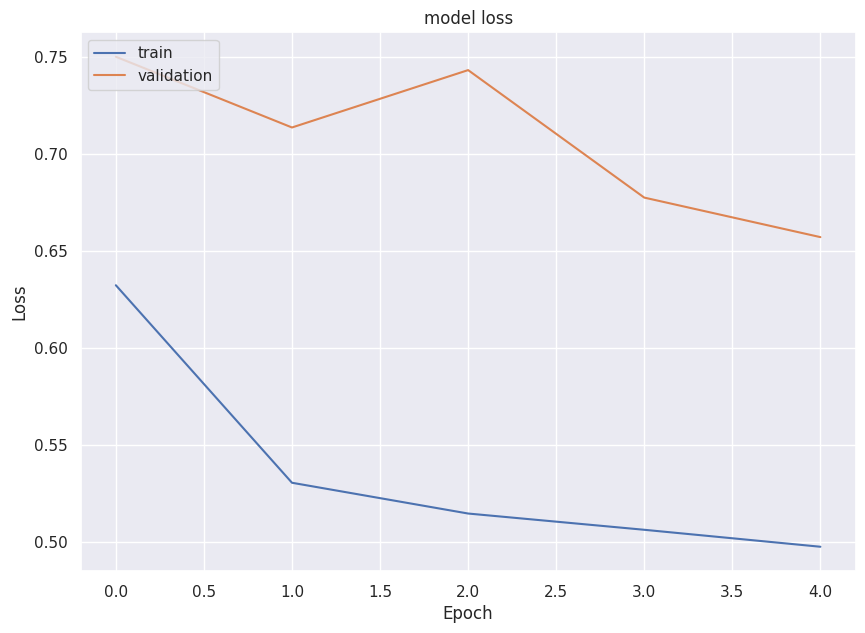

In [0]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_sm.history['loss'])
plt.plot(history_sm.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

The balance strategy produced a lot of noise in the model

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Best Threshold=0.399404, G-Mean=0.736


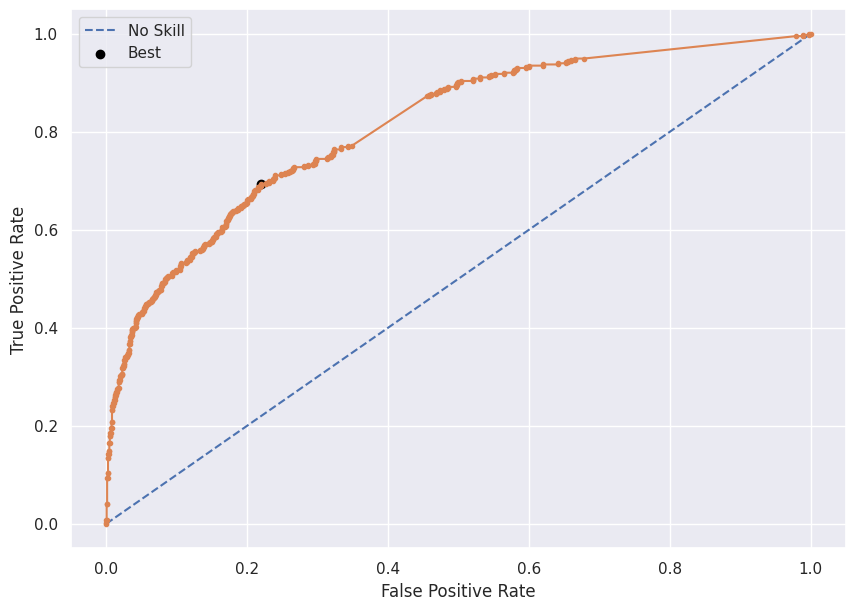

In [0]:
# predict probabilities
yhat_sm = model_sm.predict(X_test)
# keep probabilities for the positive outcome only
yhat_sm = yhat_sm[:, 0]
# calculate roc curves
fpr, tpr, thresholds_sm = roc_curve(y_test, yhat_sm)
# calculate the g-mean for each threshold
gmeans_sm = np.sqrt(tpr * (1-fpr))
# locate the index of the largest g-mean
ix = np.argmax(gmeans_sm)
print('Best Threshold=%f, G-Mean=%.3f' % (thresholds_sm[ix], gmeans_sm[ix]))
# plot the roc curve for the model
pyplot.plot([0,1], [0,1], linestyle='--', label='No Skill')
pyplot.plot(fpr, tpr, marker='.')
pyplot.scatter(fpr[ix], tpr[ix], marker='o', color='black', label='Best')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
pyplot.legend()
# show the plot
pyplot.show()

In [0]:
y_pred_sm=model_sm.predict(X_test)
y_pred_sm = (y_pred_sm > thresholds_sm[ix])
y_pred_sm

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [ True]])

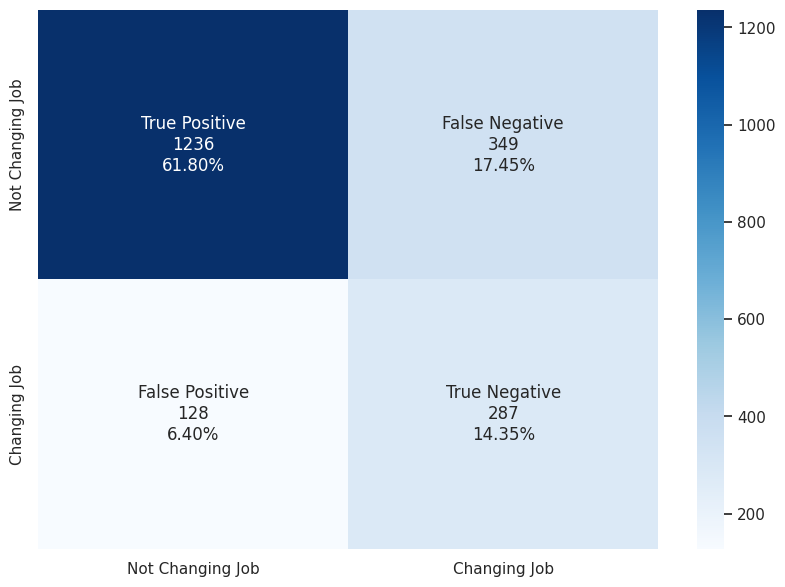

In [0]:
#Calculating the confusion matrix
from sklearn.metrics import confusion_matrix
cm_sm=confusion_matrix(y_test, y_pred_sm)
labels = ['True Positive','False Negative','False Positive','True Negative']
categories = [ 'Not Changing Job','Changing Job']
make_confusion_matrix(cm_sm,
                      group_names=labels,
                      categories=categories,
                      cmap='Blues')

In [0]:
#Accuracy as per the classification report
from sklearn import metrics
cr_sm=metrics.classification_report(y_test,y_pred_sm)
print(cr_sm)

              precision    recall  f1-score   support

           0       0.91      0.78      0.84      1585
           1       0.45      0.69      0.55       415

    accuracy                           0.76      2000
   macro avg       0.68      0.74      0.69      2000
weighted avg       0.81      0.76      0.78      2000



Oversampling using smote did not help improve the recall score.

The balanced model has:
- A recall of 0.78 for class 0
- A G-mean of 0.761


In [0]:
print("Final Model Comparison for Churners")
display(results_df.sort_values(by=["AUC","F1"], ascending=False).reset_index(drop=True))

Final Model Comparison


Model,Accuracy,Precision,Recall,F1,AUC,G-mean
Model 2 — Dropout+Adam,0.871,0.803088803088803,0.5012048192771085,0.6172106824925816,0.8715305385580175,0.6964752143083016
Model 3 — GridSearch+Adam,0.8625,0.7573529411764706,0.4963855421686747,0.5997088791848617,0.8595796434951161,0.6897215817172696
Model 1 — Adam,0.851,0.6918032786885245,0.5084337349397591,0.5861111111111111,0.8556041199498309,0.69157831592901
Model 0 — SGD,0.844,0.7877094972067039,0.3397590361445783,0.47474747474747475,0.8285507962449166,0.5758588313446639
Model 4 — SMOTE+Adam,0.802,0.5213483146067416,0.5590361445783133,0.5395348837209303,0.8113465850784843,0.6956365082768442


- **Accuracy:**
  - Highest with Dropout+Adam (0.871) and GridSearch+Adam (0.863).
  - Lowest with SMOTE+Adam (0.802).

- **Recall (catching churners):**
  - Best with SMOTE+Adam (0.56).
  - All others hover around 0.50.
  - Baseline SGD is very poor (0.34) → misses most churners.

- **Precision (avoiding false alarms):**
  - Highest with Dropout+Adam (0.80).
  - SMOTE+Adam has lowest precision (0.52) — it catches more churners but with more false positives.

- **AUC (discrimination ability):**
  - Strongest with Dropout+Adam (0.872).
  - SMOTE+Adam still decent (0.811).

- **G-mean (balance between churners and non-churners):**
  - Very similar for Dropout+Adam (0.696) and SMOTE+Adam (0.696).
  - Lowest for SGD (0.576).

### Final Model Selection

#### Summary:

- **Model 2 (Dropout+Adam)** achieved the highest accuracy (0.871), precision (0.80), and AUC (0.872).  
- **Model 4 (SMOTE+Adam)** achieved the highest recall (0.56) and one of the best G-mean scores (~0.696).  
- **Model 0 (SGD baseline)** performed worst, with recall only 0.34, making it unsuitable for this business case.  

#### Conclusion:
For churn prediction, the bank’s priority is to **catch as many churners as possible** (high recall), even if that lowers accuracy slightly.  
Therefore, **Model 4 — SMOTE+Adam** is the best choice, as it provides the most balanced performance while identifying more churn-prone customers.  


## Actionable Insights & Recommendations
<br>

#### Actionable Insights
- **Churn profile**: Customers who are older, less active, and hold fewer products are at higher risk of leaving
- **Activity matters**: Inactive members showed significantly higher churn. Driving engagement (e.g., mobile banking, offers, personalized notifications) can reduce exits
- **Product portfolio**: Customers with only one product churn more. Banks can encourage cross-selling (credit card, loan, or savings account bundling)
- **Geography differences**: Certain regions have higher churn. Localized campaigns or region-specific offers can be effective
- **Monitoring**: Retrain this churn model **quarterly** to adapt to changing customer behavior

#### Business Recommendations
- **Focus on high-risk segments**: older, inactive customers, and those with only one product
- **Boost engagement**: drive digital channel usage (app/online banking) with rewards and offers 
- **Cross-sell & bundling**: promote multiple products to improve stickiness
- **Localized campaigns**: tailor retention efforts to regions with higher churn
- **Ongoing monitoring**: retrain the churn model quarterly to adapt to changing behavior

